# Análisis de Variabilidad Hospitalaria — Egresos GRD Chile 2023
### Ministerio de Salud / FONASA · Pregunta de investigación 8
---
**Fuente:** Egresos hospitalarios GRD 2023 (muestra ~1.04M registros)  
**Variables clave:** estancia, severidad clínica, peso GRD, tipo de alta, diagnóstico principal  
**Objetivo:** Determinar si existe variabilidad hospitalaria en procedimientos, estancias y resultados clínicos para pacientes con diagnósticos similares.

## 1. Configuración del entorno e importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Configuración del estilo visual de los gráficos
### Definir parámetros para que todas las figuras tengan presentación consistente
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120
})

### Definir paleta de colores para usar en los gráficos
### Mantener consistencia visual: rojo para malo, verde para bueno, etc.
PALETA = {
    'rojo':   '#E24B4A',
    'ambar':  '#EF9F27',
    'verde':  '#1D9E75',
    'azul':   '#378ADD',
    'purpura':'#7F77DD',
    'gris':   '#888780'
}

### Confirmar que se cargó todo sin problemas
print("Librerías importadas correctamente")


Librerías importadas correctamente


## 2. Carga y limpieza preliminar de datos

In [ ]:
### Rutas de los archivos CSV que contienen los datos
RUTA_GRD        = "GRD_2023_muestra.csv"
RUTA_HOSPITALES = "Hospitales.csv"
RUTA_IRGRD      = "IR-GRD.csv"
RUTA_SEVERIDAD  = "Severidad.csv"

### Cargar archivo principal de egresos
df = pd.read_csv(RUTA_GRD, sep="|", low_memory=False)

### Cargar tabla maestra de hospitales y limpiar espacios en blanco
hosp = pd.read_csv(RUTA_HOSPITALES, sep="|", header=None,
                   names=["COD_HOSPITAL", "NOMBRE_HOSPITAL"])
hosp['COD_HOSPITAL']   = hosp['COD_HOSPITAL'].astype(str).str.strip().astype(int)
hosp['NOMBRE_HOSPITAL']= hosp['NOMBRE_HOSPITAL'].str.strip()

### Cargar tabla de diagnósticos GRD
irgrd = pd.read_csv(RUTA_IRGRD, sep="|", header=None,
                    names=["COD_GRD", "NOMBRE_GRD"])
irgrd['COD_GRD'] = irgrd['COD_GRD'].astype(str).str.strip()

### Crear nuevas variables para facilitar análisis
### Convertir severidad de texto a número
df['SEVERIDAD']       = pd.to_numeric(df['IR_29301_SEVERIDAD'], errors='coerce')
### Crear variable binaria para fallecidos (1=sí, 0=no)
df['FALLECIDO']       = (df['TIPOALTA'] == 'FALLECIDO').astype(int)
### Limpiar código de diagnóstico GRD
df['COD_GRD_CLEAN']   = df['IR_29301_COD_GRD'].astype(str).str.strip()
### Convertir fecha de ingreso a formato datetime
df['FECHA_INGRESO_DT']= pd.to_datetime(df['FECHA_INGRESO'], format='%Y-%m-%d', errors='coerce')
### Extraer mes de la fecha para análisis de estacionalidad
df['MES_INGRESO']     = df['FECHA_INGRESO_DT'].dt.month
### Agrupar edad en intervalos para análisis demográfico
df['GRUPO_EDAD']      = pd.cut(df['EDAD_INGRESO'],
                                bins=[0,14,29,44,59,74,200],
                                labels=['0-14','15-29','30-44','45-59','60-74','75+'])

### Unir datos maestros de hospitales y diagnósticos
df = df.merge(hosp, on='COD_HOSPITAL', how='left')
df = df.merge(irgrd, left_on='COD_GRD_CLEAN', right_on='COD_GRD', how='left')

### Mostrar resumen de la carga
print(f"Registros totales : {len(df):,}")
print(f"Hospitales únicos : {df['COD_HOSPITAL'].nunique()}")
print(f"Columnas          : {list(df.columns)}")
df.head(3)


Registros totales : 1,039,577
Hospitales únicos : 68
Columnas          : ['COD_HOSPITAL', 'CIP_ENCRIPTADO', 'SEXO', 'FECHA_NACIMIENTO', 'SERVICIO_SALUD', 'FECHA_INGRESO', 'FECHAALTA', 'TIPOALTA', 'DIAGNOSTICO1', 'IR_29301_COD_GRD', 'IR_29301_PESO', 'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD', 'TIPO_FECHA_NACIMIENTO', 'TIPO_FECHA_INGRESO', 'TIPO_FECHAALTA', 'EDAD_INGRESO', 'ESTANCIA', 'ESTANCIA_INT', 'SEVERIDAD', 'FALLECIDO', 'COD_GRD_CLEAN', 'FECHA_INGRESO_DT', 'MES_INGRESO', 'GRUPO_EDAD', 'NOMBRE_HOSPITAL', 'COD_GRD', 'NOMBRE_GRD']


,COD_HOSPITAL,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,...,ESTANCIA_INT,SEVERIDAD,FALLECIDO,COD_GRD_CLEAN,FECHA_INGRESO_DT,MES_INGRESO,GRUPO_EDAD,NOMBRE_HOSPITAL,COD_GRD,NOMBRE_GRD
0,122100,72196813,HOMBRE,1980-04-13,VALDIVIA,2023-03-12,2023-03-14,DOMICILIO,K35.3,064161,...,2,1.0,0,064161,2023-03-12,3,30-44,Hospital Clínico Regional (Valdivia),NaN,NaN
1,114101,DESCONOCIDO,HOMBRE,2001-11-04,METROPOLITANO SURORIENTE,2023-11-04,2023-11-10,DOMICILIO,J93.1,041301,...,6,1.0,0,041301,2023-11-04,11,15-29,Complejo Hospitalario Dr. Sótero del Río (Sant...,NaN,NaN
2,114101,97627974,HOMBRE,2020-07-30,METROPOLITANO SURORIENTE,2023-06-07,2023-06-08,HOSPITALIZACIÓN DOMICILIARIA,J12.1,044161,...,1,1.0,0,044161,2023-06-07,6,0-14,Complejo Hospitalario Dr. Sótero del Río (Sant...,NaN,NaN


In [3]:
### Análisis descriptivo inicial — vemos cómo se comportan las variables clave
print('ANÁLISIS DESCRIPTIVO INICIAL — VARIABLES CLAVE')

### Estadísticas de estancia: media, mediana, std, percentiles
print('\n── Estancia (días) ──')
estancia = df['ESTANCIA'].dropna()
print(f'  Media              : {estancia.mean():.2f} días')
print(f'  Mediana            : {estancia.median():.2f} días')
print(f'  Desviación estándar: {estancia.std():.2f} días')  ### std es importante porque la distribución es asimétrica
print(f'  Varianza           : {estancia.var():.2f}')
print(f'  P25                : {estancia.quantile(0.25):.2f} días')
print(f'  P75                : {estancia.quantile(0.75):.2f} días')
print(f'  P90                : {estancia.quantile(0.90):.2f} días')
print(f'  Mínimo / Máximo    : {estancia.min()} / {estancia.max()} días')

### Ver distribución de severidad con etiquetas descriptivas
print('\n── Severidad clínica ──')
sev_map = {0:'Sin gravedad', 1:'Menor', 2:'Moderada', 3:'Mayor'}
sev_counts = df['SEVERIDAD'].value_counts().sort_index()
for k, v in sev_counts.items():
    if pd.notna(k):
        print(f'  {int(k)} - {sev_map.get(int(k),"?"):15s}: {v:>8,}  ({v/len(df)*100:.1f}%)')

### Ver tipos de alta — nos interesa identificar cuántos son fallecidos
print('\n── Tipo de alta (top 8) ──')
for t, n in df['TIPOALTA'].value_counts().head(8).items():
    print(f'  {t:50s}: {n:>7,}  ({n/len(df)*100:.1f}%)')

### Distribución por sexo
print('\n── Sexo ──')
for s, n in df['SEXO'].value_counts().items():
    print(f'  {s:12s}: {n:>8,}  ({n/len(df)*100:.1f}%)')

### Identificar valores nulos — importante antes de cualquier análisis
print('\n── Valores nulos por columna ──')
nulos = df.isnull().sum()
print(nulos[nulos > 0])


ANÁLISIS DESCRIPTIVO INICIAL — VARIABLES CLAVE

── Estancia (días) ──
  Media              : 5.80 días
  Mediana            : 2.00 días
  Desviación estándar: 12.35 días
  Varianza           : 152.48
  P25                : 1.00 días
  P75                : 6.00 días
  P90                : 14.00 días
  Mínimo / Máximo    : 0 / 696 días

── Severidad clínica ──
  0 - Sin gravedad   :  193,546  (18.6%)
  1 - Menor          :  388,693  (37.4%)
  2 - Moderada       :  253,083  (24.3%)
  3 - Mayor          :  204,225  (19.6%)

── Tipo de alta (top 8) ──
  DOMICILIO                                         : 936,197  (90.1%)
  HOSPITALIZACIÓN DOMICILIARIA                      :  29,297  (2.8%)
  FALLECIDO                                         :  25,136  (2.4%)
  DERIVACIÓN OTRO HOSPITAL DEL SERVICIO             :  20,504  (2.0%)
  ALTA VOLUNTARIA                                   :  10,317  (1.0%)
  DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL       :   7,472  (0.7%)
  DERIVACIÓN A OTROS CENTR

### 2.2 Análisis de Outliers — Método IQR

Para detectar valores atípicos en la variable `ESTANCIA` usamos el criterio IQR:
un valor se considera outlier si cae fuera del rango `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.
Esto es importante porque estancias extremadamente largas pueden distorsionar las medias.


=== ANÁLISIS DE OUTLIERS — ESTANCIA ===
  Q1 (P25)            : 1.0 días
  Q3 (P75)            : 6.0 días
  IQR                 : 5.0 días
  Límite inferior     : -6.5 días (valores < esto = outlier)
  Límite superior     : 13.5 días (valores > esto = outlier)
  Total outliers      : 106,346 registros (10.23%)

── Outliers por severidad ──
  Sev 0 (Sin gravedad):     19 outliers de 193,546 (0.0%)
  Sev 1 (Menor       ): 16,264 outliers de 388,693 (4.2%)
  Sev 2 (Moderada    ): 30,952 outliers de 253,083 (12.2%)
  Sev 3 (Mayor       ): 59,093 outliers de 204,225 (28.9%)

⚠️  Nota: los outliers de estancia alta corresponden principalmente a
   pacientes de mayor severidad (casos reales, no errores de datos).
   Para visualizaciones se truncará la escala a 30 días para mayor claridad.


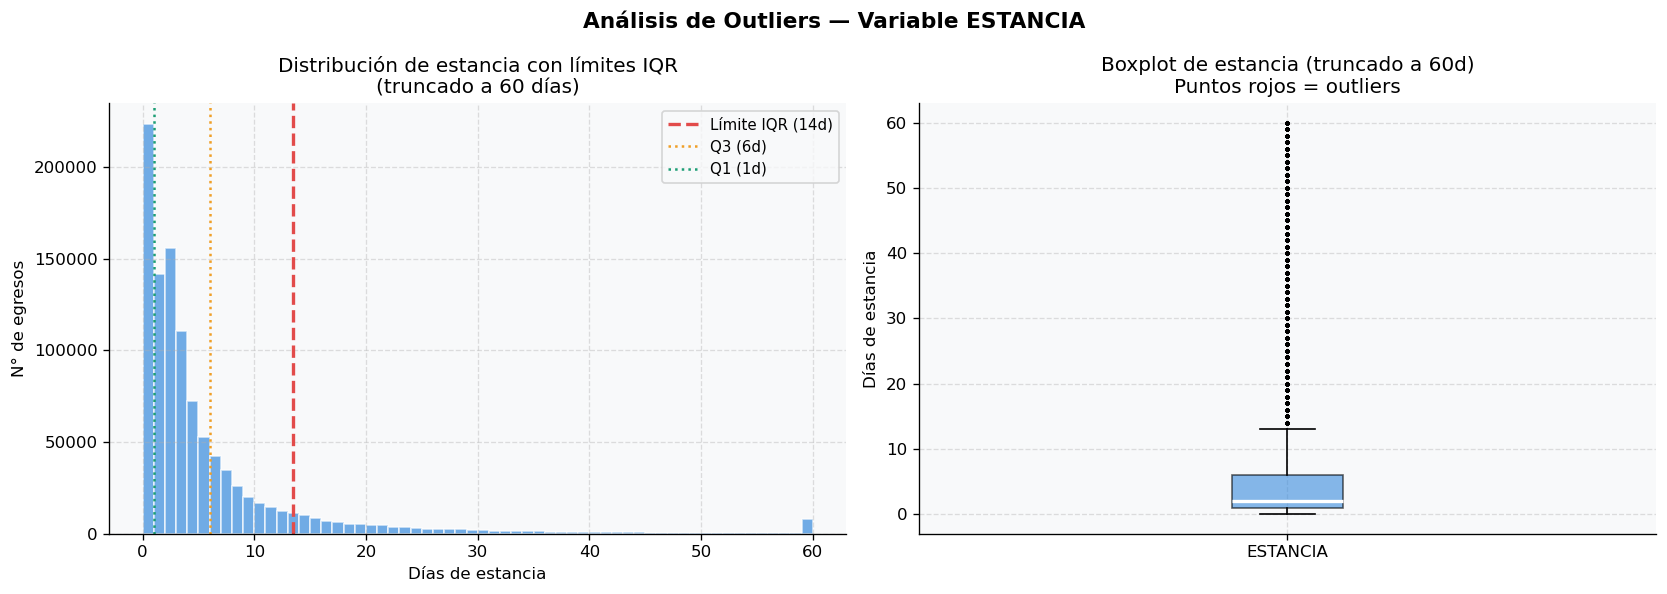

In [4]:
### Análisis formal de outliers en la variable ESTANCIA usando método IQR
### Este criterio es estándar: outlier si está más allá de 1.5 veces el rango intercuartílico

Q1  = df['ESTANCIA'].quantile(0.25)
Q3  = df['ESTANCIA'].quantile(0.75)
IQR = Q3 - Q1

### Calcular límites de la zona 'normal'
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

### Identificar registros con valores atípicos
outliers     = df[(df['ESTANCIA'] < limite_inf) | (df['ESTANCIA'] > limite_sup)]
pct_outliers = len(outliers) / len(df) * 100

print('=== ANÁLISIS DE OUTLIERS — ESTANCIA ===')
print(f'  Q1 (P25)            : {Q1:.1f} días')
print(f'  Q3 (P75)            : {Q3:.1f} días')
print(f'  IQR                 : {IQR:.1f} días')
print(f'  Límite inferior     : {limite_inf:.1f} días (valores < esto = outlier)')
print(f'  Límite superior     : {limite_sup:.1f} días (valores > esto = outlier)')
print(f'  Total outliers      : {len(outliers):,} registros ({pct_outliers:.2f}%)')

### Desglose de outliers por severidad — para ver si los outliers tienen sentido clínico
print('\n── Outliers por severidad ──')
sev_map = {0:'Sin gravedad', 1:'Menor', 2:'Moderada', 3:'Mayor'}
for sev in [0, 1, 2, 3]:
    n_out = len(outliers[outliers['SEVERIDAD'] == sev])
    n_tot = len(df[df['SEVERIDAD'] == sev])
    if n_tot > 0:
        print(f'  Sev {sev} ({sev_map[sev]:12s}): {n_out:>6,} outliers de {n_tot:>7,} ({n_out/n_tot*100:.1f}%)')

### Para el análisis NO eliminamos los outliers clínicos (estancias largas = casos graves reales)
### Solo los documentamos para que el lector sepa que existen
print('\n⚠️  Nota: los outliers de estancia alta corresponden principalmente a')
print('   pacientes de mayor severidad (casos reales, no errores de datos).')
print('   Para visualizaciones se truncará la escala a 30 días para mayor claridad.')

### Visualizar distribución con límite IQR marcado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

### Panel izquierdo: distribución completa con líneas de outlier
ax1 = axes[0]
ax1.hist(df['ESTANCIA'].clip(upper=60), bins=60, color=PALETA['azul'], alpha=0.7, edgecolor='white')
ax1.axvline(limite_sup, color=PALETA['rojo'], linewidth=2, linestyle='--', label=f'Límite IQR ({limite_sup:.0f}d)')
ax1.axvline(Q3, color=PALETA['ambar'], linewidth=1.5, linestyle=':', label=f'Q3 ({Q3:.0f}d)')
ax1.axvline(Q1, color=PALETA['verde'], linewidth=1.5, linestyle=':', label=f'Q1 ({Q1:.0f}d)')
ax1.set_title('Distribución de estancia con límites IQR\n(truncado a 60 días)', fontsize=12)
ax1.set_xlabel('Días de estancia')
ax1.set_ylabel('N° de egresos')
ax1.legend(fontsize=9)

### Panel derecho: boxplot para visualizar outliers de forma estándar
ax2 = axes[1]
ax2.boxplot(df['ESTANCIA'].clip(upper=60), vert=True, patch_artist=True,
            boxprops=dict(facecolor=PALETA['azul'], alpha=0.6),
            medianprops=dict(color='white', linewidth=2),
            flierprops=dict(marker='.', color=PALETA['rojo'], alpha=0.3, markersize=2))
ax2.set_title('Boxplot de estancia (truncado a 60d)\nPuntos rojos = outliers', fontsize=12)
ax2.set_ylabel('Días de estancia')
ax2.set_xticklabels(['ESTANCIA'])

plt.suptitle('Análisis de Outliers — Variable ESTANCIA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outliers_estancia.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.3 Histogramas — Distribución de Variables Clave

Visualizamos la distribución de las variables principales del dataset: `ESTANCIA`, `SEVERIDAD` y `EDAD_INGRESO`.
Los histogramas nos permiten detectar asimetría, multimodalidad y valores extremos antes de hacer inferencia.


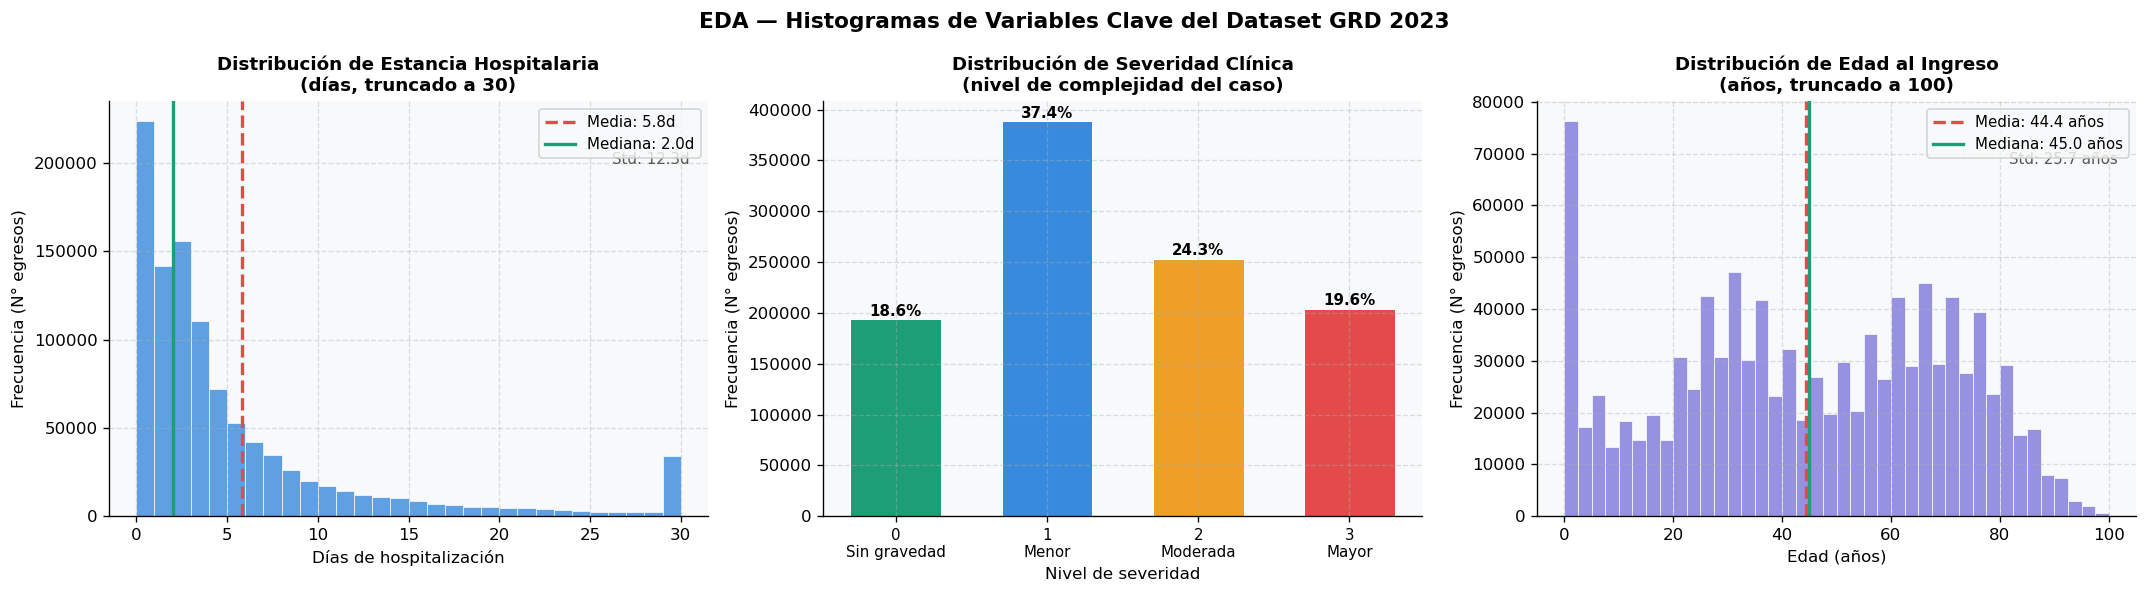

=== TABLA RESUMEN — ESTADÍSTICAS DESCRIPTIVAS COMPLETAS ===
         ESTANCIA   SEVERIDAD  EDAD_INGRESO  IR_29301_PESO
count  1039577.00  1039547.00    1039577.00     1039547.00
mean         5.80        1.45         44.45           0.96
std         12.35        1.01         25.70           1.09
min          0.00        0.00          0.00           0.00
25%          1.00        1.00         25.00           0.47
50%          2.00        1.00         45.00           0.69
75%          6.00        2.00         67.00           1.03
max        696.00        3.00        109.00          20.65


In [5]:
### Histogramas de las tres variables más importantes del EDA
### Queremos ver la forma de la distribución antes de hacer cualquier análisis estadístico

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

### --- Histograma 1: Estancia hospitalaria ---
ax1 = axes[0]
### Truncamos a 30 días porque el 90%+ de los casos están en ese rango
estancia_plot = df['ESTANCIA'].clip(upper=30)
ax1.hist(estancia_plot, bins=30, color=PALETA['azul'], alpha=0.8, edgecolor='white', linewidth=0.5)
ax1.axvline(df['ESTANCIA'].mean(),   color=PALETA['rojo'],  linewidth=2, linestyle='--',
            label=f"Media: {df['ESTANCIA'].mean():.1f}d")
ax1.axvline(df['ESTANCIA'].median(), color=PALETA['verde'], linewidth=2, linestyle='-',
            label=f"Mediana: {df['ESTANCIA'].median():.1f}d")
ax1.set_title('Distribución de Estancia Hospitalaria\n(días, truncado a 30)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Días de hospitalización', fontsize=10)
ax1.set_ylabel('Frecuencia (N° egresos)', fontsize=10)
ax1.legend(fontsize=9)
### La media > mediana confirma asimetría positiva (right-skewed)
ax1.text(0.97, 0.85, f'Std: {df["ESTANCIA"].std():.1f}d', transform=ax1.transAxes,
         ha='right', fontsize=9, color='#555')

### --- Histograma 2: Severidad clínica ---
ax2 = axes[1]
sev_vals = df['SEVERIDAD'].dropna()
colores_sev_hist = [PALETA['verde'], PALETA['azul'], PALETA['ambar'], PALETA['rojo']]
sev_counts_hist = sev_vals.value_counts().sort_index()
### Graficamos como barras porque la variable es ordinal (4 categorías discretas)
bars = ax2.bar(sev_counts_hist.index.astype(int), sev_counts_hist.values,
               color=colores_sev_hist, edgecolor='white', linewidth=0.6, width=0.6)
sev_labels = {0:'Sin gravedad', 1:'Menor', 2:'Moderada', 3:'Mayor'}
ax2.set_xticks([0, 1, 2, 3])
ax2.set_xticklabels([f'{i}\n{sev_labels[i]}' for i in range(4)], fontsize=9)
ax2.set_title('Distribución de Severidad Clínica\n(nivel de complejidad del caso)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Nivel de severidad', fontsize=10)
ax2.set_ylabel('Frecuencia (N° egresos)', fontsize=10)
### Agregar etiquetas de porcentaje sobre cada barra
for bar, val in zip(bars, sev_counts_hist.values):
    pct = val / len(sev_vals) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

### --- Histograma 3: Edad al ingreso ---
ax3 = axes[2]
edad_vals = df['EDAD_INGRESO'].dropna().clip(upper=100)
ax3.hist(edad_vals, bins=40, color=PALETA['purpura'], alpha=0.8, edgecolor='white', linewidth=0.5)
ax3.axvline(edad_vals.mean(),   color=PALETA['rojo'],  linewidth=2, linestyle='--',
            label=f"Media: {edad_vals.mean():.1f} años")
ax3.axvline(edad_vals.median(), color=PALETA['verde'], linewidth=2, linestyle='-',
            label=f"Mediana: {edad_vals.median():.1f} años")
ax3.set_title('Distribución de Edad al Ingreso\n(años, truncado a 100)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Edad (años)', fontsize=10)
ax3.set_ylabel('Frecuencia (N° egresos)', fontsize=10)
ax3.legend(fontsize=9)
ax3.text(0.97, 0.85, f'Std: {edad_vals.std():.1f} años', transform=ax3.transAxes,
         ha='right', fontsize=9, color='#555')

plt.suptitle('EDA — Histogramas de Variables Clave del Dataset GRD 2023',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_histogramas_eda.png', dpi=150, bbox_inches='tight')
plt.show()

### Resumen estadístico completo incluyendo desviación estándar
print('=== TABLA RESUMEN — ESTADÍSTICAS DESCRIPTIVAS COMPLETAS ===')
print(df[['ESTANCIA', 'SEVERIDAD', 'EDAD_INGRESO', 'IR_29301_PESO']].describe().round(2).to_string())


## 3. Variabilidad en estancia hospitalaria
### 3.1 Mediana nacional de estancia por nivel de severidad

In [6]:
mediana_nacional = (df[df['SEVERIDAD'].isin([0,1,2,3])]
                   .groupby('SEVERIDAD')['ESTANCIA'].median())
print("Mediana nacional de estancia por severidad:")
for s, m in mediana_nacional.items():
    print(f"  Severidad {int(s)} ({sev_map[int(s)]:12s}): {m:.0f} días")

Mediana nacional de estancia por severidad:
  Severidad 0 (Sin gravedad): 0 días
  Severidad 1 (Menor       ): 2 días
  Severidad 2 (Moderada    ): 4 días
  Severidad 3 (Mayor       ): 7 días


### 3.2 Resumen por hospital (con ≥500 egresos)

In [7]:
### Filtrar hospitales con volumen mínimo (evita ruido estadístico)
### Solo hospitales con 500 o más egresos en el período
hosp_counts  = df.groupby('COD_HOSPITAL').size()
big_hospitals= hosp_counts[hosp_counts >= 500].index
df_big       = df[df['COD_HOSPITAL'].isin(big_hospitals)].copy()
print(f"Hospitales con ≥500 egresos: {len(big_hospitals)}")
print(f"Registros en subconjunto   : {len(df_big):,}")

### Calcular estadísticas principales por hospital
resumen_hosp = df_big.groupby('COD_HOSPITAL').agg(
    n_egresos       =('ESTANCIA','count'),
    estancia_media  =('ESTANCIA','mean'),
    estancia_mediana=('ESTANCIA','median'),
    severidad_media =('SEVERIDAD','mean'),
    peso_medio      =('IR_29301_PESO','mean'),
    mortalidad_pct  =('FALLECIDO', lambda x: x.mean()*100),
).reset_index().merge(hosp, on='COD_HOSPITAL', how='left')

print("\n── Top 10 por estancia MAYOR ──")
print(resumen_hosp.nlargest(10,'estancia_media')
      [['NOMBRE_HOSPITAL','n_egresos','estancia_media','severidad_media','mortalidad_pct']]
      .to_string(index=False))

print("\n── Top 10 por estancia MENOR ──")
print(resumen_hosp.nsmallest(10,'estancia_media')
      [['NOMBRE_HOSPITAL','n_egresos','estancia_media','severidad_media','mortalidad_pct']]
      .to_string(index=False))


Hospitales con ≥500 egresos: 68
Registros en subconjunto   : 1,039,577

── Top 10 por estancia MAYOR ──
                                                      NOMBRE_HOSPITAL  n_egresos  estancia_media  severidad_media  mortalidad_pct
                    Hospital Dr. Eduardo Pereira Ramírez (Valparaíso)       4818       10.046492         1.728933        3.071814
  Instituto Nacional de Enfermedades Respiratorias y Cirugía Torácica       3594        8.979967         2.126043        4.368392
        Hospital de Urgencia Asistencia Pública Dr. Alejandro del Río      11238        8.952305         1.963695        5.988610
                           Hospital Dr. Leonardo Guzmán (Antofagasta)      21076        7.616104         1.436231        3.297590
Hospital Clínico Metropolitano El Carmen Doctor Luis Valentín Ferrada      20412        7.295316         1.711885        3.968254
                  Hospital Barros Luco Trudeau (Santiago, San Miguel)      26701        7.156698         1.586532   

### 3.3 Scatter: estancia media vs. severidad promedio del casemix

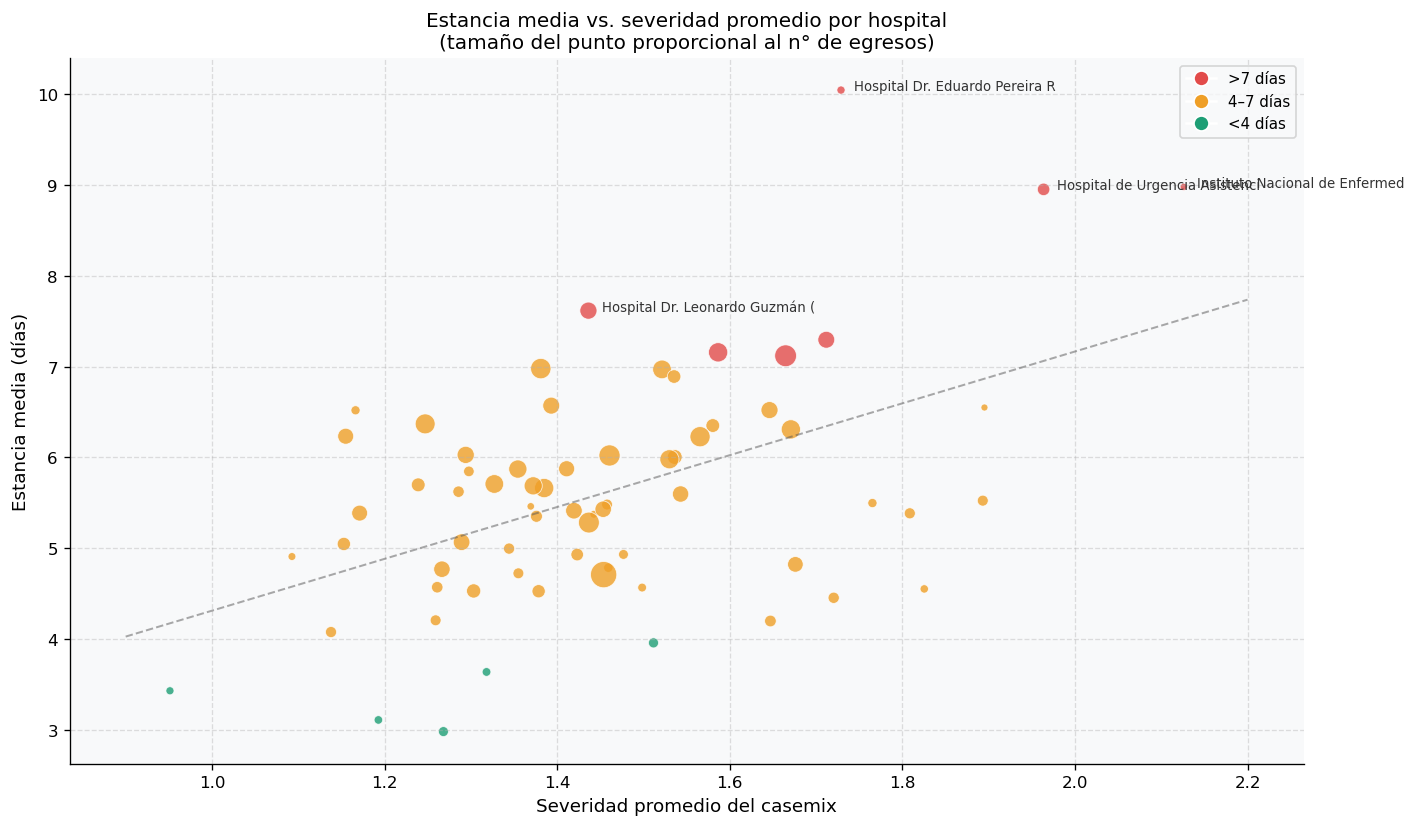

In [8]:
from scipy import stats

fig, ax = plt.subplots(figsize=(12, 7))

### Asignar colores según rango de estancia (rojo=largo, verde=corto)
colores = resumen_hosp['estancia_media'].apply(
    lambda x: PALETA['rojo'] if x > 7 else PALETA['ambar'] if x > 4 else PALETA['verde'])

### Graficar dispersión: severidad vs estancia de cada hospital
ax.scatter(resumen_hosp['severidad_media'],
           resumen_hosp['estancia_media'],
           c=colores, s=resumen_hosp['n_egresos']/200,
           alpha=0.8, edgecolors='white', linewidth=0.5)

### Calcular línea de tendencia para visualizar la relación
slope, intercept, r, p, _ = stats.linregress(
    resumen_hosp['severidad_media'].dropna(),
    resumen_hosp['estancia_media'].dropna())
x_range = np.linspace(0.9, 2.2, 50)
ax.plot(x_range, intercept + slope * x_range, '--',
        color='#555', alpha=0.5, linewidth=1.2, label=f'Tendencia (R={r:.2f})')

### Etiquetar hospitales con estancia muy elevada
top5 = resumen_hosp.nlargest(4,'estancia_media')
for _, row in top5.iterrows():
    ax.annotate(row['NOMBRE_HOSPITAL'][:30],
                (row['severidad_media'], row['estancia_media']),
                fontsize=8, ha='left',
                xytext=(8,0), textcoords='offset points', color='#333')

ax.set_xlabel("Severidad promedio del casemix", fontsize=11)
ax.set_ylabel("Estancia media (días)", fontsize=11)
ax.set_title("Estancia media vs. severidad promedio por hospital\n"
             "(tamaño del punto proporcional al n° de egresos)", fontsize=12)

from matplotlib.lines import Line2D
### Crear leyenda personalizada
leyenda = [Line2D([0],[0],marker='o',color='w',markerfacecolor=PALETA['rojo'],markersize=9,label='>7 días'),
           Line2D([0],[0],marker='o',color='w',markerfacecolor=PALETA['ambar'],markersize=9,label='4–7 días'),
           Line2D([0],[0],marker='o',color='w',markerfacecolor=PALETA['verde'],markersize=9,label='<4 días')]
ax.legend(handles=leyenda, fontsize=9)
plt.tight_layout()
plt.savefig("fig_01_estancia_severidad.png", dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Eficiencia hospitalaria — exceso de estancia ajustado por peso GRD

Regresión nacional estancia ~ peso GRD:
  Estancia = 0.74 + 5.26 × PesoGRD   (R = 0.465)


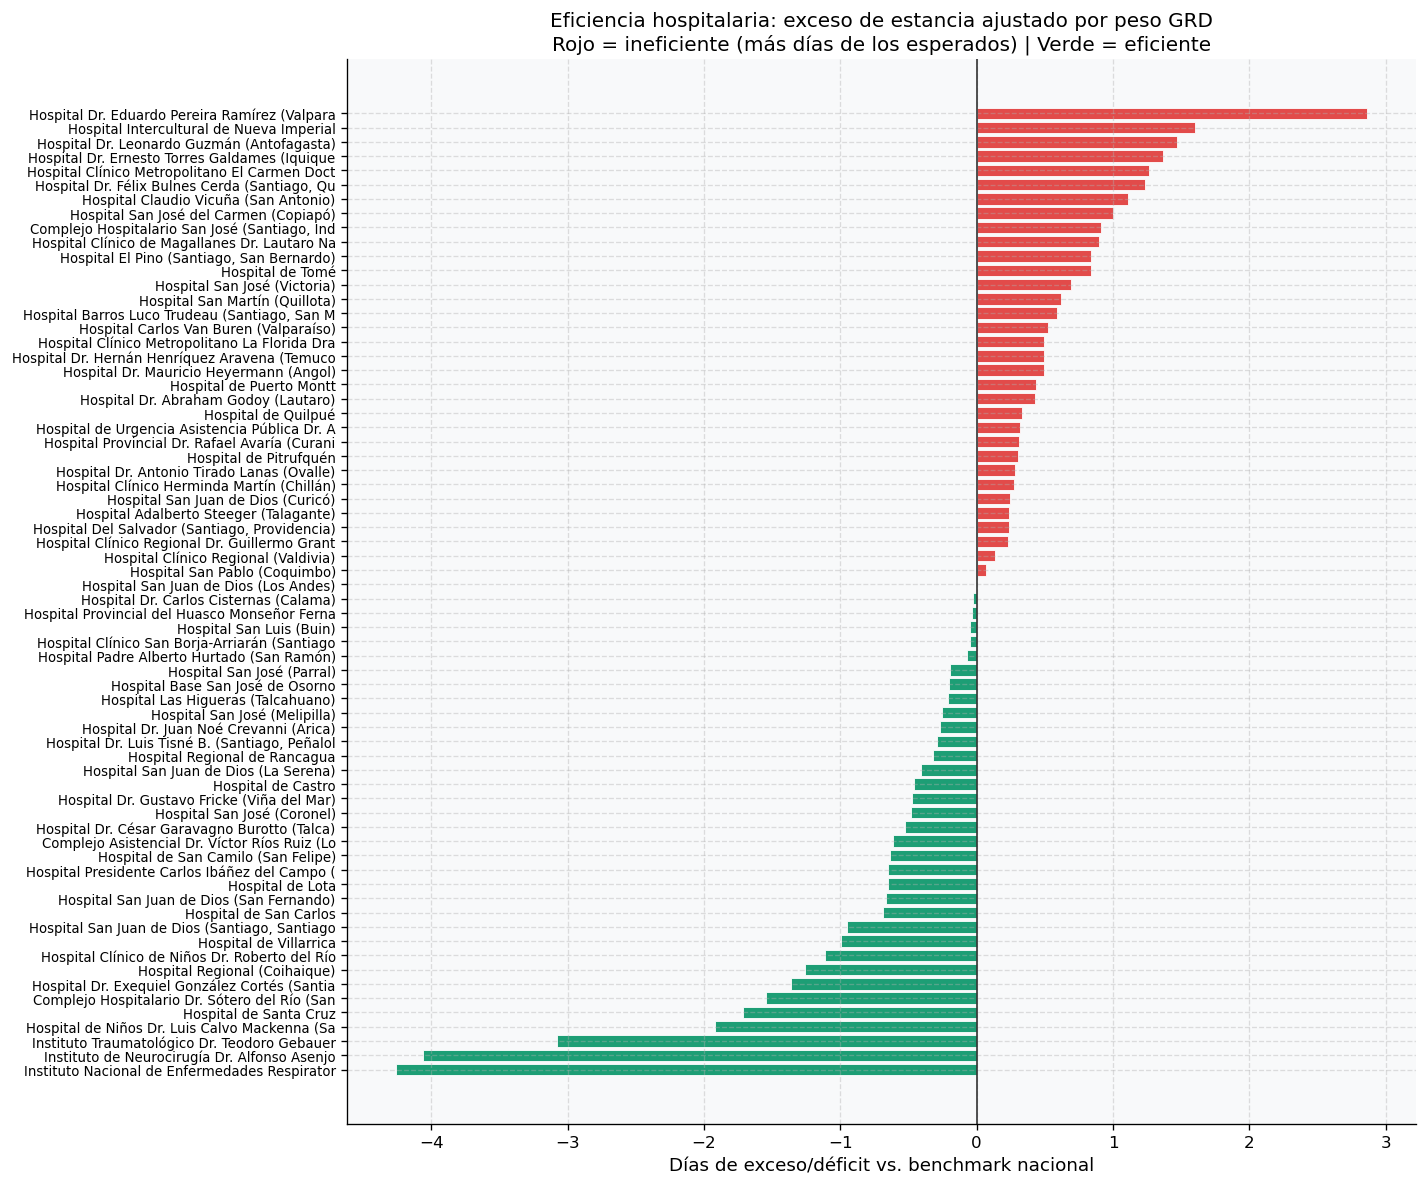


Top 5 más ineficientes:
                                                      NOMBRE_HOSPITAL  estancia_media  estancia_esperada  exceso_estancia
Hospital Clínico Metropolitano El Carmen Doctor Luis Valentín Ferrada        7.295316           6.027882         1.267435
                       Hospital Dr. Ernesto Torres Galdames (Iquique)        6.569335           5.203748         1.365587
                           Hospital Dr. Leonardo Guzmán (Antofagasta)        7.616104           6.148222         1.467882
                             Hospital Intercultural de Nueva Imperial        6.518068           4.916745         1.601323
                    Hospital Dr. Eduardo Pereira Ramírez (Valparaíso)       10.046492           7.179396         2.867096

Top 5 más eficientes:
                                                    NOMBRE_HOSPITAL  estancia_media  estancia_esperada  exceso_estancia
Instituto Nacional de Enfermedades Respiratorias y Cirugía Torácica        8.979967          13.2401

In [9]:
### Usar regresión lineal nacional para establecer benchmark
### Esto nos permite medir eficiencia de cada hospital
df_r = df[['ESTANCIA','IR_29301_PESO','SEVERIDAD','COD_HOSPITAL']].dropna()
slope_g, intercept_g, r_g, _, _ = stats.linregress(df_r['IR_29301_PESO'], df_r['ESTANCIA'])
print(f"Regresión nacional estancia ~ peso GRD:")
print(f"  Estancia = {intercept_g:.2f} + {slope_g:.2f} × PesoGRD   (R = {r_g:.3f})")

### Calcular eficiencia: estancia observada vs esperada
eficiencia = df_r.groupby('COD_HOSPITAL').apply(lambda g: pd.Series({
    'n': len(g),
    'estancia_media': g['ESTANCIA'].mean(),
    'peso_medio':     g['IR_29301_PESO'].mean(),
})).reset_index()

eficiencia = eficiencia[eficiencia['n'] >= 500].merge(hosp, on='COD_HOSPITAL', how='left')
### Calcular estancia esperada según el modelo nacional
eficiencia['estancia_esperada'] = intercept_g + slope_g * eficiencia['peso_medio']
### Diferencia: positiva = más días de los esperados (ineficiente)
eficiencia['exceso_estancia']   = eficiencia['estancia_media'] - eficiencia['estancia_esperada']
eficiencia_sorted = eficiencia.sort_values('exceso_estancia', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
### Rojo para ineficientes, verde para eficientes
colores_eff = [PALETA['rojo'] if x > 0 else PALETA['verde']
               for x in eficiencia_sorted['exceso_estancia']]
bars = ax.barh(eficiencia_sorted['NOMBRE_HOSPITAL'].str[:45],
               eficiencia_sorted['exceso_estancia'],
               color=colores_eff, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='#333', linewidth=1.0)
ax.set_xlabel("Días de exceso/déficit vs. benchmark nacional", fontsize=11)
ax.set_title("Eficiencia hospitalaria: exceso de estancia ajustado por peso GRD\n"
             "Rojo = ineficiente (más días de los esperados) | Verde = eficiente", fontsize=12)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig("fig_02_eficiencia_estancia.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 más ineficientes:")
print(eficiencia_sorted.tail(5)[['NOMBRE_HOSPITAL','estancia_media','estancia_esperada','exceso_estancia']].to_string(index=False))
print("\nTop 5 más eficientes:")
print(eficiencia_sorted.head(5)[['NOMBRE_HOSPITAL','estancia_media','estancia_esperada','exceso_estancia']].to_string(index=False))


## 4. Mortalidad hospitalaria ajustada por severidad (SMR)
**Razón Estandarizada de Mortalidad (SMR)** = mortalidad observada / mortalidad esperada según distribución de severidad del hospital.  
SMR > 1 indica más muertes de lo esperado para ese mix de pacientes.

In [10]:
### Calcular tasa de mortalidad nacional por nivel de severidad
### Este es el benchmark para comparar hospitales
mort_nac_por_sev = df.groupby('SEVERIDAD')['FALLECIDO'].mean()
print("Mortalidad nacional por severidad:")
for s, m in mort_nac_por_sev.items():
    if pd.notna(s):
        print(f"  Severidad {int(s)} ({sev_map[int(s)]:12s}): {m*100:.2f}%")

### Resumir datos de mortalidad por hospital
### Usar mínimo 1000 egresos para evitar inestabilidad estadística
hosp_mort = df.groupby('COD_HOSPITAL').agg(
    n           =('FALLECIDO','count'),
    fallecidos  =('FALLECIDO','sum'),
    sev_media   =('SEVERIDAD','mean'),
    NOMBRE_HOSPITAL=('NOMBRE_HOSPITAL','first')
).reset_index()
hosp_mort['tasa_mort'] = hosp_mort['fallecidos'] / hosp_mort['n'] * 100
### Filtrar solo hospitales con volumen suficiente
hosp_mort = hosp_mort[hosp_mort['n'] >= 1000]

### Obtener distribución de severidad de cada hospital
### Necesaria para calcular mortalidad esperada
hosp_sev_dist = (df[df['COD_HOSPITAL'].isin(hosp_mort['COD_HOSPITAL'])]
                 .groupby(['COD_HOSPITAL','SEVERIDAD']).size()
                 .unstack(fill_value=0))
### Normalizar a proporciones
hosp_sev_dist = hosp_sev_dist.div(hosp_sev_dist.sum(axis=1), axis=0)

### Calcular mortalidad esperada según el casemix de severidad de cada hospital
### Usa la tasa nacional por severidad aplicada a la distribución local
hosp_mort_expected = pd.Series(dtype=float)
for cod in hosp_sev_dist.index:
    exp = sum(hosp_sev_dist.loc[cod, s] * mort_nac_por_sev.get(s, 0)
              for s in [0.0, 1.0, 2.0, 3.0])
    hosp_mort_expected[cod] = exp * 100

hosp_mort = hosp_mort.set_index('COD_HOSPITAL')
hosp_mort['mort_esperada'] = hosp_mort_expected
### SMR (Standardized Mortality Ratio): observada/esperada
### Si SMR > 1 significa más muertes de lo esperado
hosp_mort['SMR'] = hosp_mort['tasa_mort'] / hosp_mort['mort_esperada']
hosp_mort = hosp_mort.reset_index()

print(f"\nHospitales incluidos en SMR (n≥1000): {len(hosp_mort)}")


Mortalidad nacional por severidad:
  Severidad 0 (Sin gravedad): 0.00%
  Severidad 1 (Menor       ): 0.17%
  Severidad 2 (Moderada    ): 0.94%
  Severidad 3 (Mayor       ): 10.80%

Hospitales incluidos en SMR (n≥1000): 68


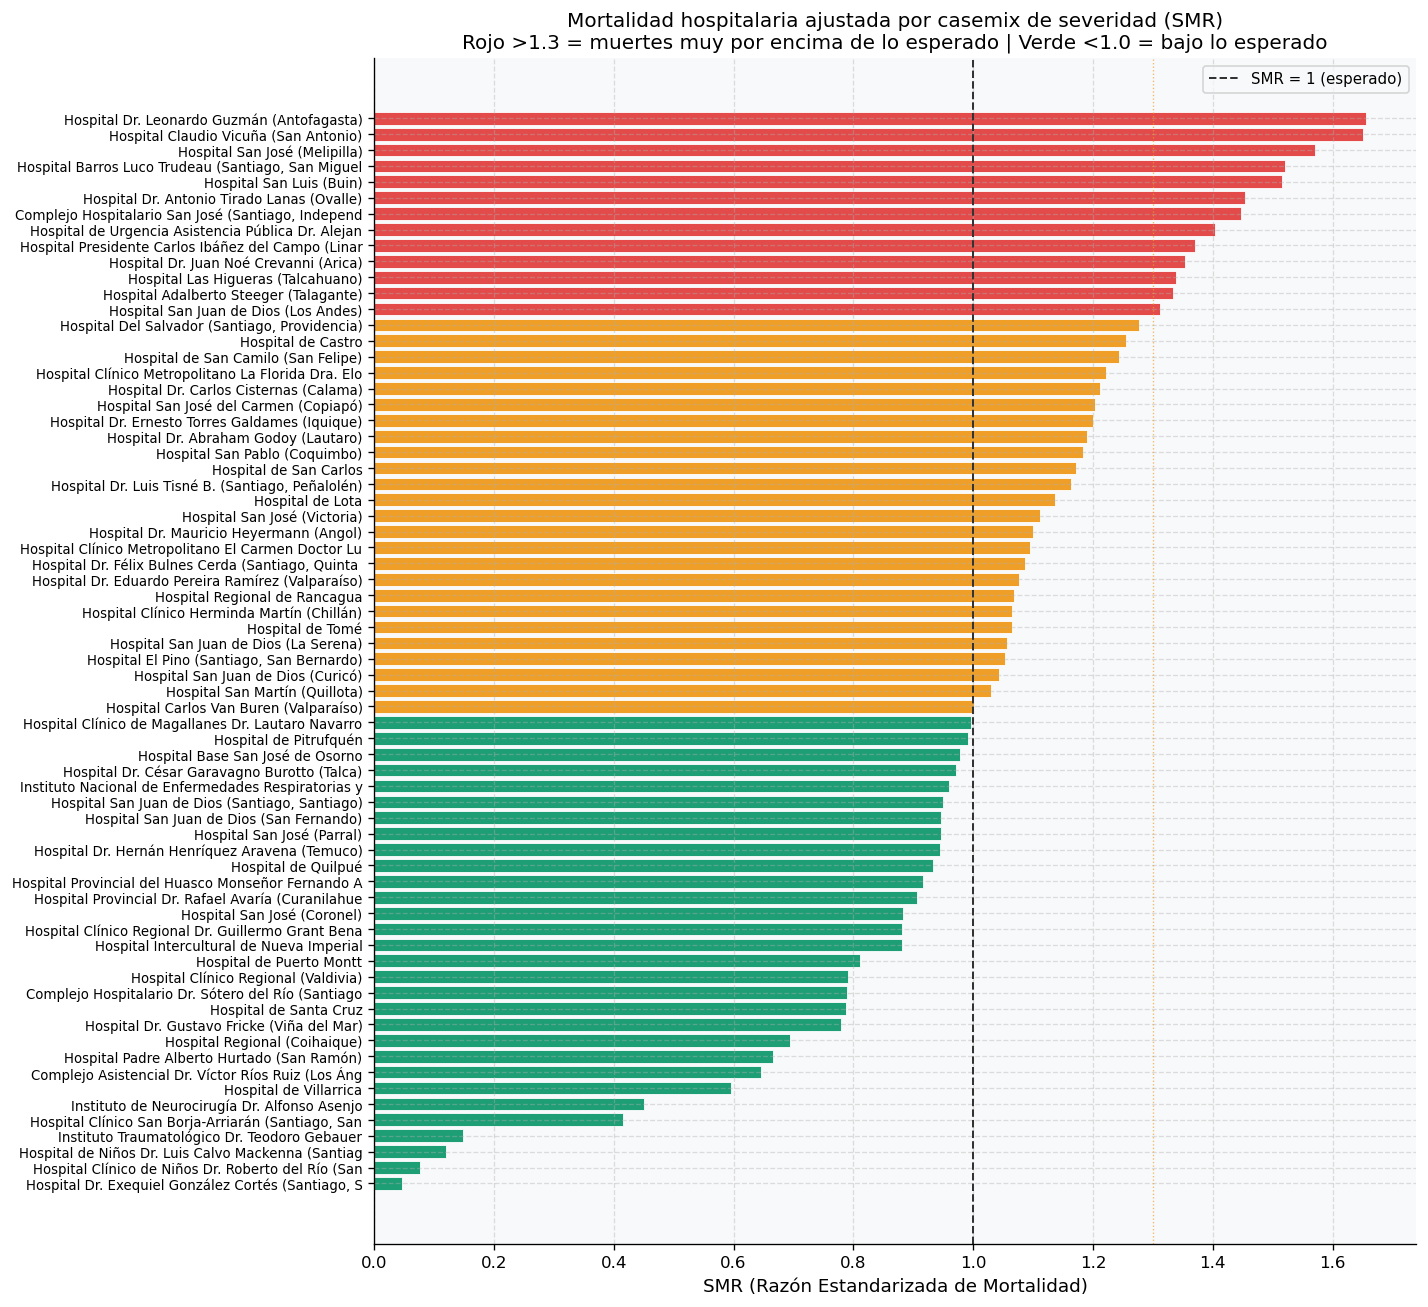

Top 10 SMR más alto:
                                              NOMBRE_HOSPITAL     n  tasa_mort  mort_esperada   SMR  sev_media
                   Hospital Dr. Leonardo Guzmán (Antofagasta) 21076      3.298          1.991 1.657      1.436
                        Hospital Claudio Vicuña (San Antonio)  9338      3.438          2.082 1.651      1.286
                                Hospital San José (Melipilla)  8895      2.080          1.325 1.570      1.138
          Hospital Barros Luco Trudeau (Santiago, San Miguel) 26701      3.779          2.486 1.520      1.587
                                     Hospital San Luis (Buin)  5557      3.113          2.055 1.515      1.498
                   Hospital Dr. Antonio Tirado Lanas (Ovalle) 12687      2.680          1.843 1.454      1.153
     Complejo Hospitalario San José (Santiago, Independencia) 28496      2.986          2.064 1.447      1.247
Hospital de Urgencia Asistencia Pública Dr. Alejandro del Río 11238      5.989          4.2

In [11]:
smr_sorted = hosp_mort.sort_values('SMR', ascending=True)

fig, ax = plt.subplots(figsize=(12, 11))
### Codificar colores: rojo si mucho exceso de muertes, verde si por debajo de lo esperado
colores_smr = [PALETA['rojo'] if x > 1.3 else
               PALETA['ambar'] if x > 1.0 else
               PALETA['verde'] for x in smr_sorted['SMR']]

ax.barh(smr_sorted['NOMBRE_HOSPITAL'].str[:50],
        smr_sorted['SMR'],
        color=colores_smr, edgecolor='white', linewidth=0.5)
ax.axvline(1.0, color='#333', linewidth=1.2, linestyle='--', label='SMR = 1 (esperado)')
ax.axvline(1.3, color=PALETA['ambar'], linewidth=0.8, linestyle=':', alpha=0.7)
ax.set_xlabel("SMR (Razón Estandarizada de Mortalidad)", fontsize=11)
ax.set_title("Mortalidad hospitalaria ajustada por casemix de severidad (SMR)\n"
             "Rojo >1.3 = muertes muy por encima de lo esperado | Verde <1.0 = bajo lo esperado", fontsize=12)
ax.tick_params(axis='y', labelsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_03_SMR_hospitales.png", dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 SMR más alto:")
print(hosp_mort.nlargest(10,'SMR')
      [['NOMBRE_HOSPITAL','n','tasa_mort','mort_esperada','SMR','sev_media']]
      .round(3).to_string(index=False))

print("\nTop 10 SMR más bajo:")
print(hosp_mort.nsmallest(10,'SMR')
      [['NOMBRE_HOSPITAL','n','tasa_mort','mort_esperada','SMR','sev_media']]
      .round(3).to_string(index=False))


## 5. Consolidación de hallazgos preliminares

Este apartado resume los principales hallazgos observados en el análisis descriptivo del dataset de egresos hospitalarios GRD 2023.

### 5.1 Investigación sobre el data set

**Características generales del dataset:**
- **Volumen:** ~1.04 millones de registros de egresos hospitalarios
- **Período:** 2023
- **Cobertura:** Hospitales del sistema de FONASA
- **Variables:** Estancia, severidad clínica, peso GRD, tipo de alta, diagnóstico

**Hallazgos clave sobre la calidad de datos:**
- Completitud de variables de severidad y estancia
- Presencia de hospitales con diferentes volúmenes de egresos
- Variabilidad significativa en prácticas clínicas entre establecimientos

### 5.2 Desarrollo del glosario de términos

| Término | Definición |
|---------|-----------|
| **GRD** | Grupos Relacionados por el Diagnóstico (DRG). Sistema de clasificación que agrupa pacientes con diagnósticos y procedimientos similares |
| **Severidad** | Nivel de complejidad clínica del caso (0=sin gravedad, 1=menor, 2=moderada, 3=mayor) |
| **Estancia** | Número de días que el paciente permanece hospitalizado |
| **Peso GRD** | Factor numérico que refleja la intensidad de recursos esperados para ese grupo diagnóstico |
| **SMR** | Razón Estandarizada de Mortalidad (Standardized Mortality Ratio). Cociente entre mortalidad observada y esperada |
| **Casemix** | Composición o mezcla de casos (diferente distribución de severidades) que atiende cada hospital |
| **Mortalidad esperada** | Tasa de mortalidad ajustada según la severidad del casemix hospitalario |

### 5.3 Definición de variables a analizar

| Variable | Definición operacional | Tipo | Rol en análisis |
|----------|----------------------|------|-----------------|
| **ESTANCIA** | Número de días entre ingreso y egreso | Continua | Variable de resultado (eficiencia) |
| **FALLECIDO** | Binaria: 1 si tipo de alta = "FALLECIDO", 0 en caso contrario | Dicotómica | Variable de resultado (calidad/seguridad) |
| **SEVERIDAD** | Nivel de complejidad (0,1,2,3) del GRD | Ordinal | Variable de ajuste (casemix) |
| **PESO GRD** | Factor de recursos del grupo diagnóstico | Continua | Variable de ajuste (complejidad) |
| **COD_HOSPITAL / NOMBRE_HOSPITAL** | Identificador y nombre del establecimiento | Categórica | Variable de agrupación |
| **EDAD_INGRESO** | Edad en años al ingreso | Continua | Variable de contexto |
| **SEXO** | Género del paciente | Categórica | Variable de contexto |
| **TIPOALTA** | Tipo de egreso (alta domiciliaria, derivación, defunción, etc.) | Categórica | Variable de contexto |

## 5.4 Preguntas de investigación — Desarrollo con código y gráficos

Cada pregunta de investigación se desarrolla con el código analítico correspondiente y su visualización.  
El análisis utiliza los datos de egresos GRD 2023 (~1.04M registros, 68 hospitales).

---
### Pregunta 1: ¿Aumenta la estancia hospitalaria a medida que sube la severidad clínica?

**Hipótesis:** A mayor severidad clínica, mayor duración de la hospitalización.  
**Método:** Comparación de medianas y distribuciones de estancia por nivel de severidad (0–3). Se usa la mediana en lugar de la media por la asimetría marcada de la variable estancia.

Estadísticas de estancia por nivel de severidad:
 SEVERIDAD      n  Mediana (días)  Media (días)  P25  P75
       0.0 193546             0.0      0.075197  0.0  0.0
       1.0 388693             2.0      3.878426  1.0  4.0
       2.0 253083             4.0      6.812970  2.0  8.0
       3.0 204225             7.0     13.606106  3.0 15.0


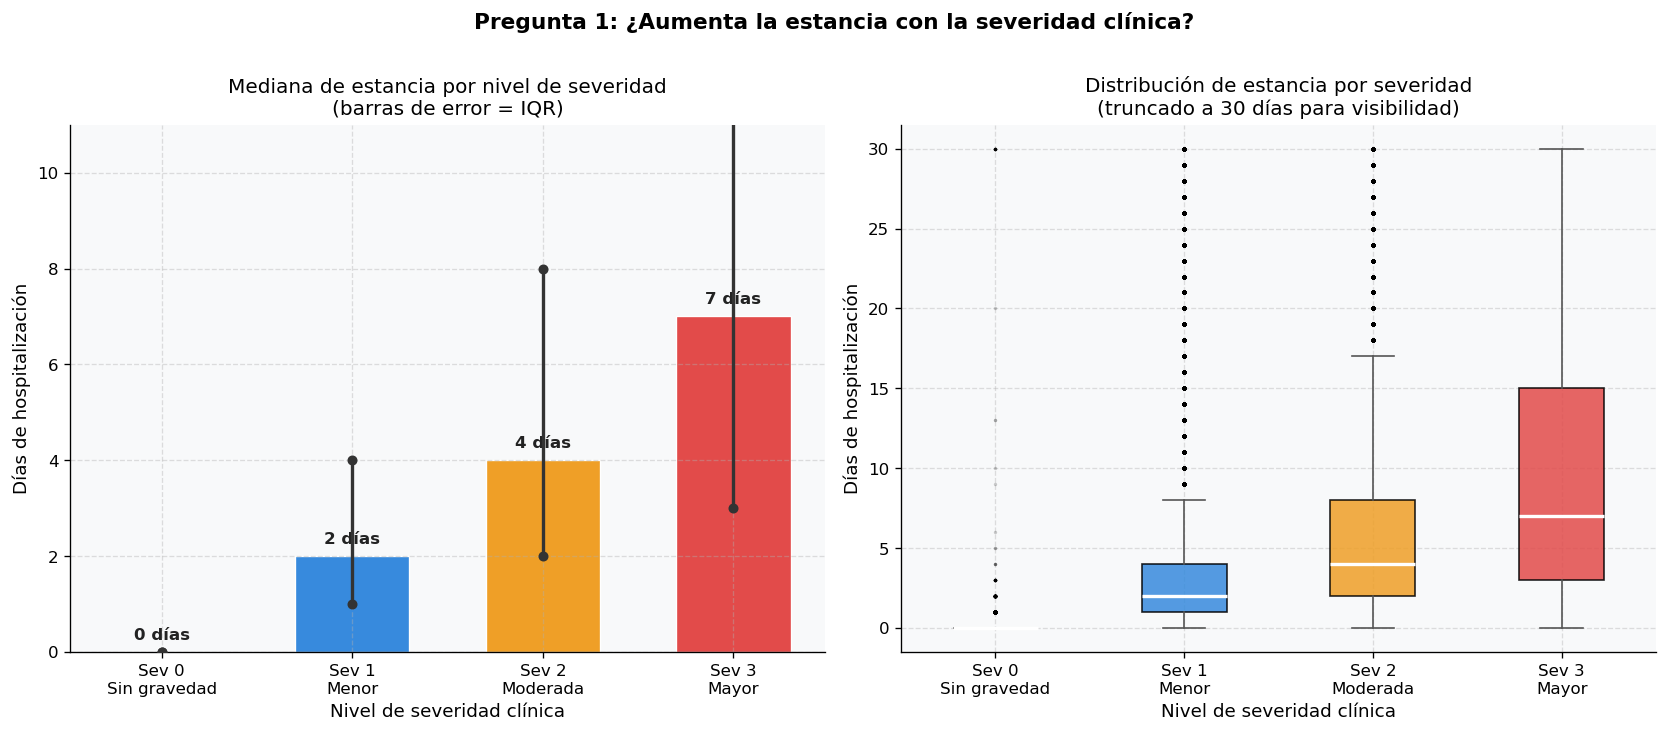


✅ RESPUESTA P1: Sí. La estancia aumenta monotónicamente con la severidad.
   Medianas: 0 días (sin gravedad) → 2 días (menor) → 4 días (moderada) → 7 días (mayor)


In [12]:
### ── PREGUNTA 1: Estancia vs Severidad clínica ──────────────────────────────

sev_map = {0: 'Sin gravedad', 1: 'Menor', 2: 'Moderada', 3: 'Mayor'}
colores_sev = [PALETA['verde'], PALETA['azul'], PALETA['ambar'], PALETA['rojo']]

### Calcular estadísticas por severidad
df_sev = df[df['SEVERIDAD'].isin([0,1,2,3])].copy()
stats_sev = df_sev.groupby('SEVERIDAD')['ESTANCIA'].agg(
    mediana='median', media='mean', q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75), n='count'
).reset_index()
stats_sev['LABEL'] = stats_sev['SEVERIDAD'].apply(lambda x: f"Sev {int(x)}\n{sev_map[int(x)]}")

print("Estadísticas de estancia por nivel de severidad:")
print(stats_sev[['SEVERIDAD','n','mediana','media','q25','q75']].rename(
    columns={'mediana':'Mediana (días)','media':'Media (días)','q25':'P25','q75':'P75'}).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

### — Panel izquierdo: barras de mediana con IQR —
ax = axes[0]
bars = ax.bar(stats_sev['LABEL'], stats_sev['mediana'],
              color=colores_sev, edgecolor='white', linewidth=0.8, width=0.6)
### Agregar barras de error (IQR)
for i, row in stats_sev.iterrows():
    ax.plot([i, i], [row['q25'], row['q75']], color='#333', linewidth=2, zorder=5)
    ax.plot(i, row['q75'], 'o', color='#333', markersize=5, zorder=6)
    ax.plot(i, row['q25'], 'o', color='#333', markersize=5, zorder=6)
    ax.text(i, row['mediana'] + 0.2, f"{row['mediana']:.0f} días",
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222')
ax.set_title("Mediana de estancia por nivel de severidad\n(barras de error = IQR)", fontsize=12)
ax.set_ylabel("Días de hospitalización", fontsize=11)
ax.set_xlabel("Nivel de severidad clínica", fontsize=11)
ax.set_ylim(0, 11)

### — Panel derecho: boxplots por severidad —
ax2 = axes[1]
datos_box = [df_sev[df_sev['SEVERIDAD'] == s]['ESTANCIA'].clip(upper=30).values
             for s in [0, 1, 2, 3]]
bp = ax2.boxplot(datos_box, patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                 flierprops=dict(marker='.', color='#aaa', alpha=0.2, markersize=2))
for patch, color in zip(bp['boxes'], colores_sev):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax2.set_xticklabels([f"Sev {int(s)}\n{sev_map[int(s)]}" for s in [0,1,2,3]])
ax2.set_title("Distribución de estancia por severidad\n(truncado a 30 días para visibilidad)", fontsize=12)
ax2.set_ylabel("Días de hospitalización", fontsize=11)
ax2.set_xlabel("Nivel de severidad clínica", fontsize=11)

plt.suptitle("Pregunta 1: ¿Aumenta la estancia con la severidad clínica?", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("fig_p1_estancia_vs_severidad.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RESPUESTA P1: Sí. La estancia aumenta monotónicamente con la severidad.")
print("   Medianas: 0 días (sin gravedad) → 2 días (menor) → 4 días (moderada) → 7 días (mayor)")

**Conclusión P1:** La relación entre severidad clínica y estancia hospitalaria es **clara, positiva y monótonamente creciente**. Cada escalón de severidad adicional prácticamente duplica la mediana de días de hospitalización. La dispersión (IQR) también aumenta con la severidad, indicando mayor variabilidad en casos más complejos.

---
### Pregunta 2: ¿Existe variabilidad hospitalaria en la duración de hospitalización después de controlar por severidad clínica?

**Hipótesis:** Si toda la variabilidad en estancia se explicara por la severidad del casemix, los residuos ajustados por peso GRD deberían ser cercanos a cero para todos los hospitales.  
**Método:** Regresión lineal nacional (estancia ~ peso GRD) → cálculo del exceso/déficit de estancia por hospital.

Regresión nacional: Estancia = 0.74 + 5.26 × PesoGRD  (R=0.465, p<0.001)


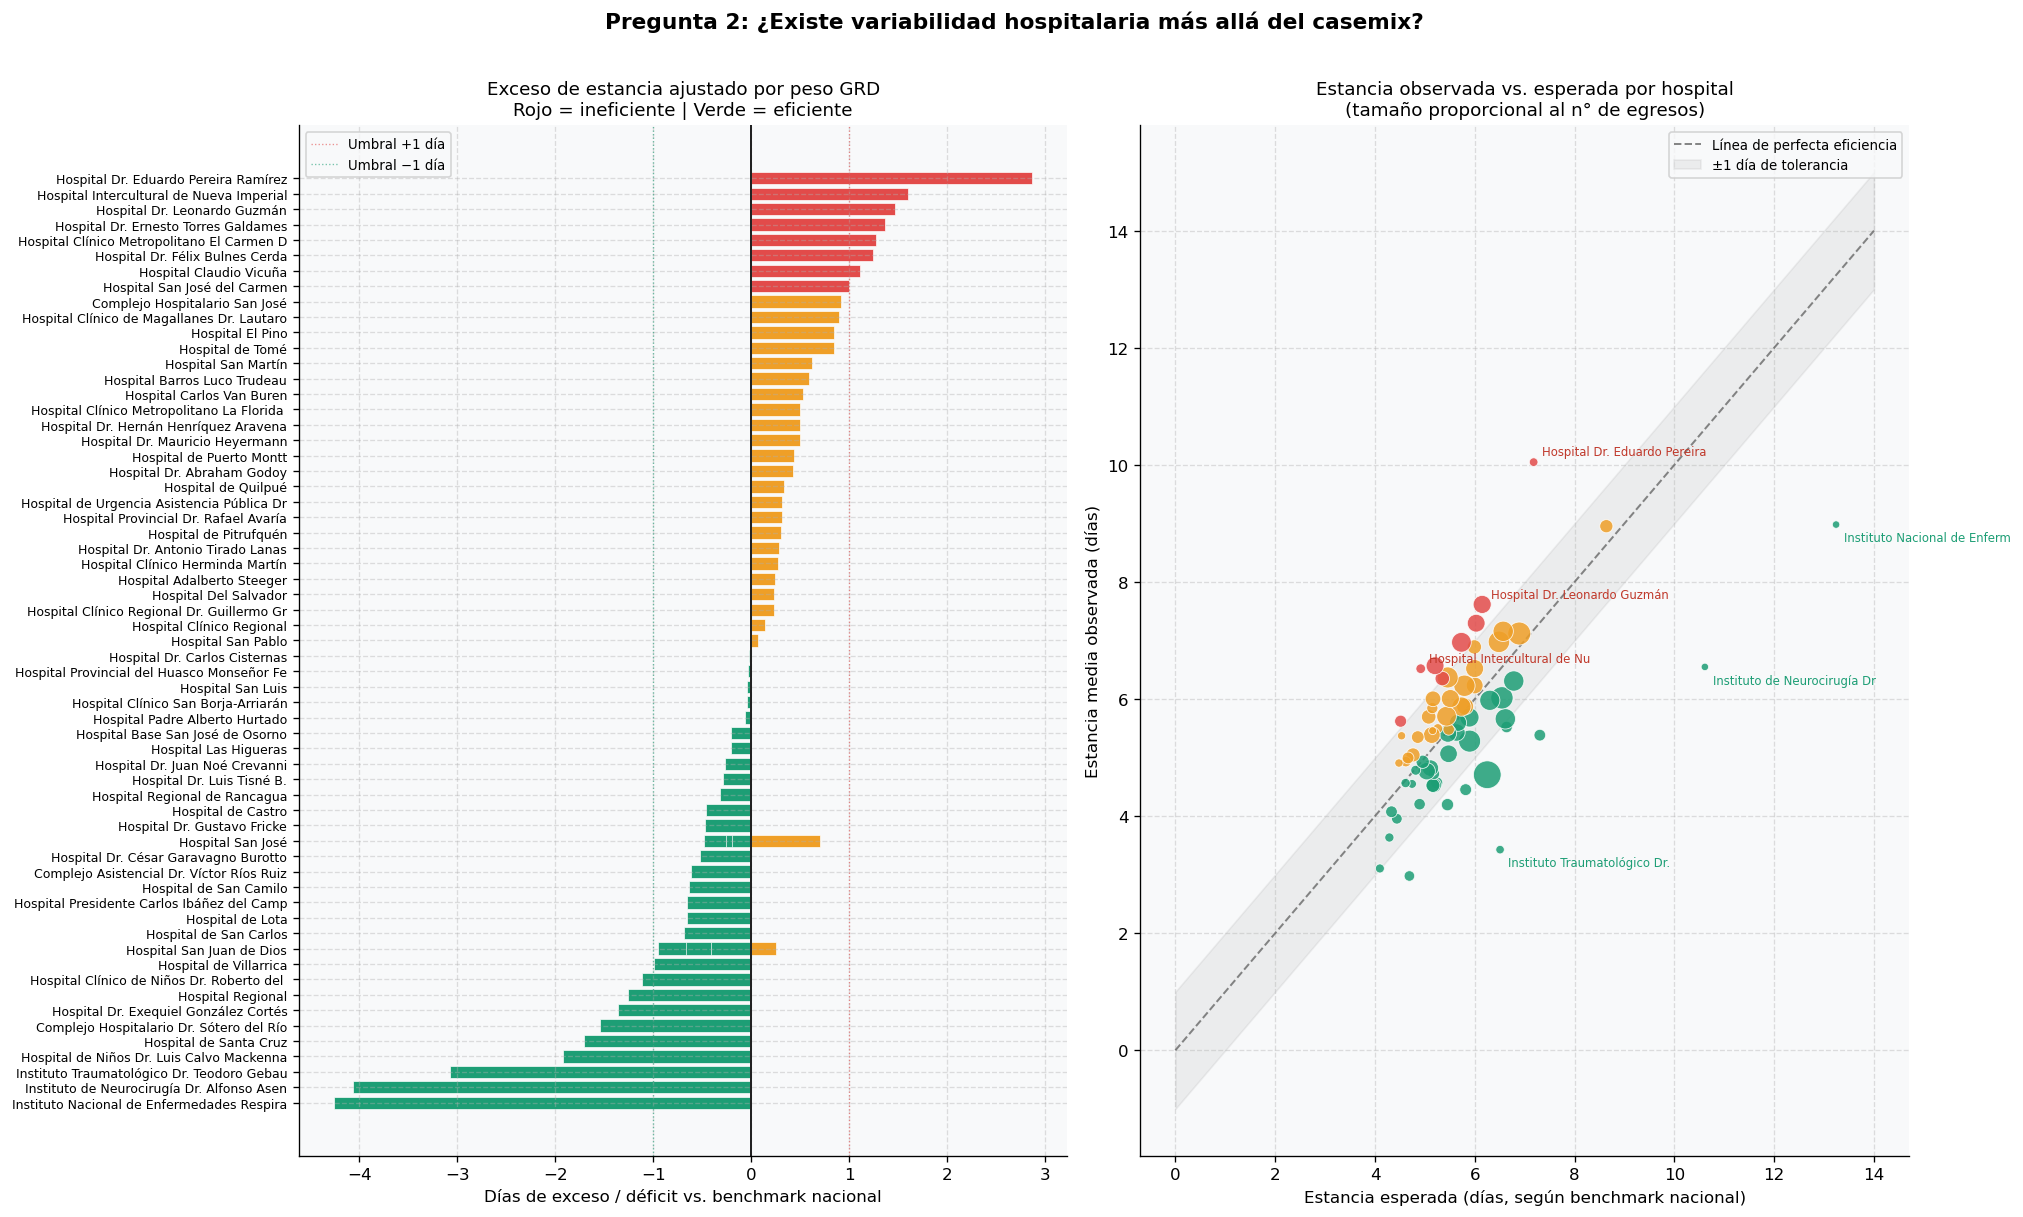


Rango total de exceso de estancia: 7.13 días
Hospitales con exceso > 1 día: 8 / 68
Hospitales con déficit > 1 día (más eficientes): 9 / 68

✅ RESPUESTA P2: Sí. La variabilidad hospitalaria en estancia va más allá del casemix.


In [13]:
### ── PREGUNTA 2: Variabilidad hospitalaria más allá del casemix ──────────────

from scipy import stats as scipy_stats

df_r = df[['ESTANCIA','IR_29301_PESO','SEVERIDAD','COD_HOSPITAL']].dropna()

### Regresión nacional: establece el benchmark esperado
slope_g, intercept_g, r_g, p_g, _ = scipy_stats.linregress(df_r['IR_29301_PESO'], df_r['ESTANCIA'])
print(f"Regresión nacional: Estancia = {intercept_g:.2f} + {slope_g:.2f} × PesoGRD  (R={r_g:.3f}, p<0.001)")

### Calcular estadísticas por hospital
eficiencia = df_r.groupby('COD_HOSPITAL').agg(
    n=('ESTANCIA', 'size'),
    estancia_media=('ESTANCIA', 'mean'),
    peso_medio=('IR_29301_PESO', 'mean')
).reset_index()

eficiencia = eficiencia[eficiencia['n'] >= 500].merge(hosp, on='COD_HOSPITAL', how='left')
eficiencia['estancia_esperada'] = intercept_g + slope_g * eficiencia['peso_medio']
eficiencia['exceso_estancia']   = eficiencia['estancia_media'] - eficiencia['estancia_esperada']
eficiencia['color'] = eficiencia['exceso_estancia'].apply(
    lambda x: PALETA['rojo'] if x > 1.0 else PALETA['ambar'] if x > 0 else PALETA['verde']
)

ef_sorted = eficiencia.sort_values('exceso_estancia')
nombre_corto = ef_sorted['NOMBRE_HOSPITAL'].str.replace(r'\s*\(.*?\)', '', regex=True).str[:42]

fig, axes = plt.subplots(1, 2, figsize=(17, 10))

### — Panel izquierdo: gráfico de barras horizontales —
ax = axes[0]
ax.barh(nombre_corto, ef_sorted['exceso_estancia'],
        color=ef_sorted['color'].values, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='#222', linewidth=1.2)
ax.axvline(1.0, color=PALETA['rojo'], linewidth=0.8, linestyle=':', alpha=0.6, label='Umbral +1 día')
ax.axvline(-1.0, color=PALETA['verde'], linewidth=0.8, linestyle=':', alpha=0.6, label='Umbral −1 día')
ax.set_xlabel("Días de exceso / déficit vs. benchmark nacional", fontsize=10)
ax.set_title("Exceso de estancia ajustado por peso GRD\nRojo = ineficiente | Verde = eficiente", fontsize=11)
ax.tick_params(axis='y', labelsize=7.5)
ax.legend(fontsize=8)

### — Panel derecho: scatter estancia observada vs esperada —
ax2 = axes[1]
sc = ax2.scatter(ef_sorted['estancia_esperada'], ef_sorted['estancia_media'],
                 c=ef_sorted['color'].values, s=ef_sorted['n']/180,
                 alpha=0.85, edgecolors='white', linewidth=0.5, zorder=3)
lims = [0, 14]
ax2.plot(lims, lims, '--', color='#555', linewidth=1.2, alpha=0.7, label='Línea de perfecta eficiencia')
ax2.fill_between(lims, [l - 1 for l in lims], [l + 1 for l in lims],
                 alpha=0.08, color='#555', label='±1 día de tolerancia')
### Etiquetar extremos
for _, row in eficiencia.nlargest(3, 'exceso_estancia').iterrows():
    ax2.annotate(row['NOMBRE_HOSPITAL'][:28], (row['estancia_esperada'], row['estancia_media']),
                 fontsize=7, xytext=(5, 4), textcoords='offset points', color='#c0392b')
for _, row in eficiencia.nsmallest(3, 'exceso_estancia').iterrows():
    ax2.annotate(row['NOMBRE_HOSPITAL'][:28], (row['estancia_esperada'], row['estancia_media']),
                 fontsize=7, xytext=(5, -10), textcoords='offset points', color='#1D9E75')
ax2.set_xlabel("Estancia esperada (días, según benchmark nacional)", fontsize=10)
ax2.set_ylabel("Estancia media observada (días)", fontsize=10)
ax2.set_title("Estancia observada vs. esperada por hospital\n(tamaño proporcional al n° de egresos)", fontsize=11)
ax2.legend(fontsize=8)

plt.suptitle("Pregunta 2: ¿Existe variabilidad hospitalaria más allá del casemix?", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("fig_p2_variabilidad_estancia.png", dpi=150, bbox_inches='tight')
plt.show()

rango = ef_sorted['exceso_estancia'].max() - ef_sorted['exceso_estancia'].min()
sobre_1 = (eficiencia['exceso_estancia'] > 1.0).sum()
bajo_m1 = (eficiencia['exceso_estancia'] < -1.0).sum()
print(f"\nRango total de exceso de estancia: {rango:.2f} días")
print(f"Hospitales con exceso > 1 día: {sobre_1} / {len(eficiencia)}")
print(f"Hospitales con déficit > 1 día (más eficientes): {bajo_m1} / {len(eficiencia)}")
print("\n✅ RESPUESTA P2: Sí. La variabilidad hospitalaria en estancia va más allá del casemix.")

**Conclusión P2:** Sí existe variabilidad hospitalaria **no explicada por el casemix**. Tras ajustar por peso GRD (complejidad del caso), la diferencia entre el hospital más ineficiente y el más eficiente supera los **7 días**. Los hospitales con exceso > 1 día respecto al benchmark sugieren factores organizacionales, protocolos o gestión de alta que explican la brecha.

---
### Pregunta 3: ¿Pacientes con diagnósticos similares reciben procedimientos diferentes dependiendo del hospital?

**Hipótesis:** Para un mismo GRD (diagnóstico y procedimiento similar), los hospitales muestran variabilidad en estancia que indica diferencias de práctica clínica.  
**Método:** Selección de los 5 GRDs más frecuentes y análisis de variabilidad inter-hospitalaria (coeficiente de variación y rango intercuartil) en estancia para cada GRD.

Variabilidad inter-hospitalaria para los GRDs más frecuentes:
  GRD 022360: mediana nacional=0d | rango hospitales=0–0d | n_hosp=50
  GRD 146101: mediana nacional=3d | rango hospitales=2–4d | n_hosp=58
  GRD 146121: mediana nacional=2d | rango hospitales=2–3d | n_hosp=57
  GRD 044163: mediana nacional=5d | rango hospitales=3–10d | n_hosp=66
  GRD 146131: mediana nacional=2d | rango hospitales=2–3d | n_hosp=58
  GRD 061131: mediana nacional=1d | rango hospitales=1–3d | n_hosp=58


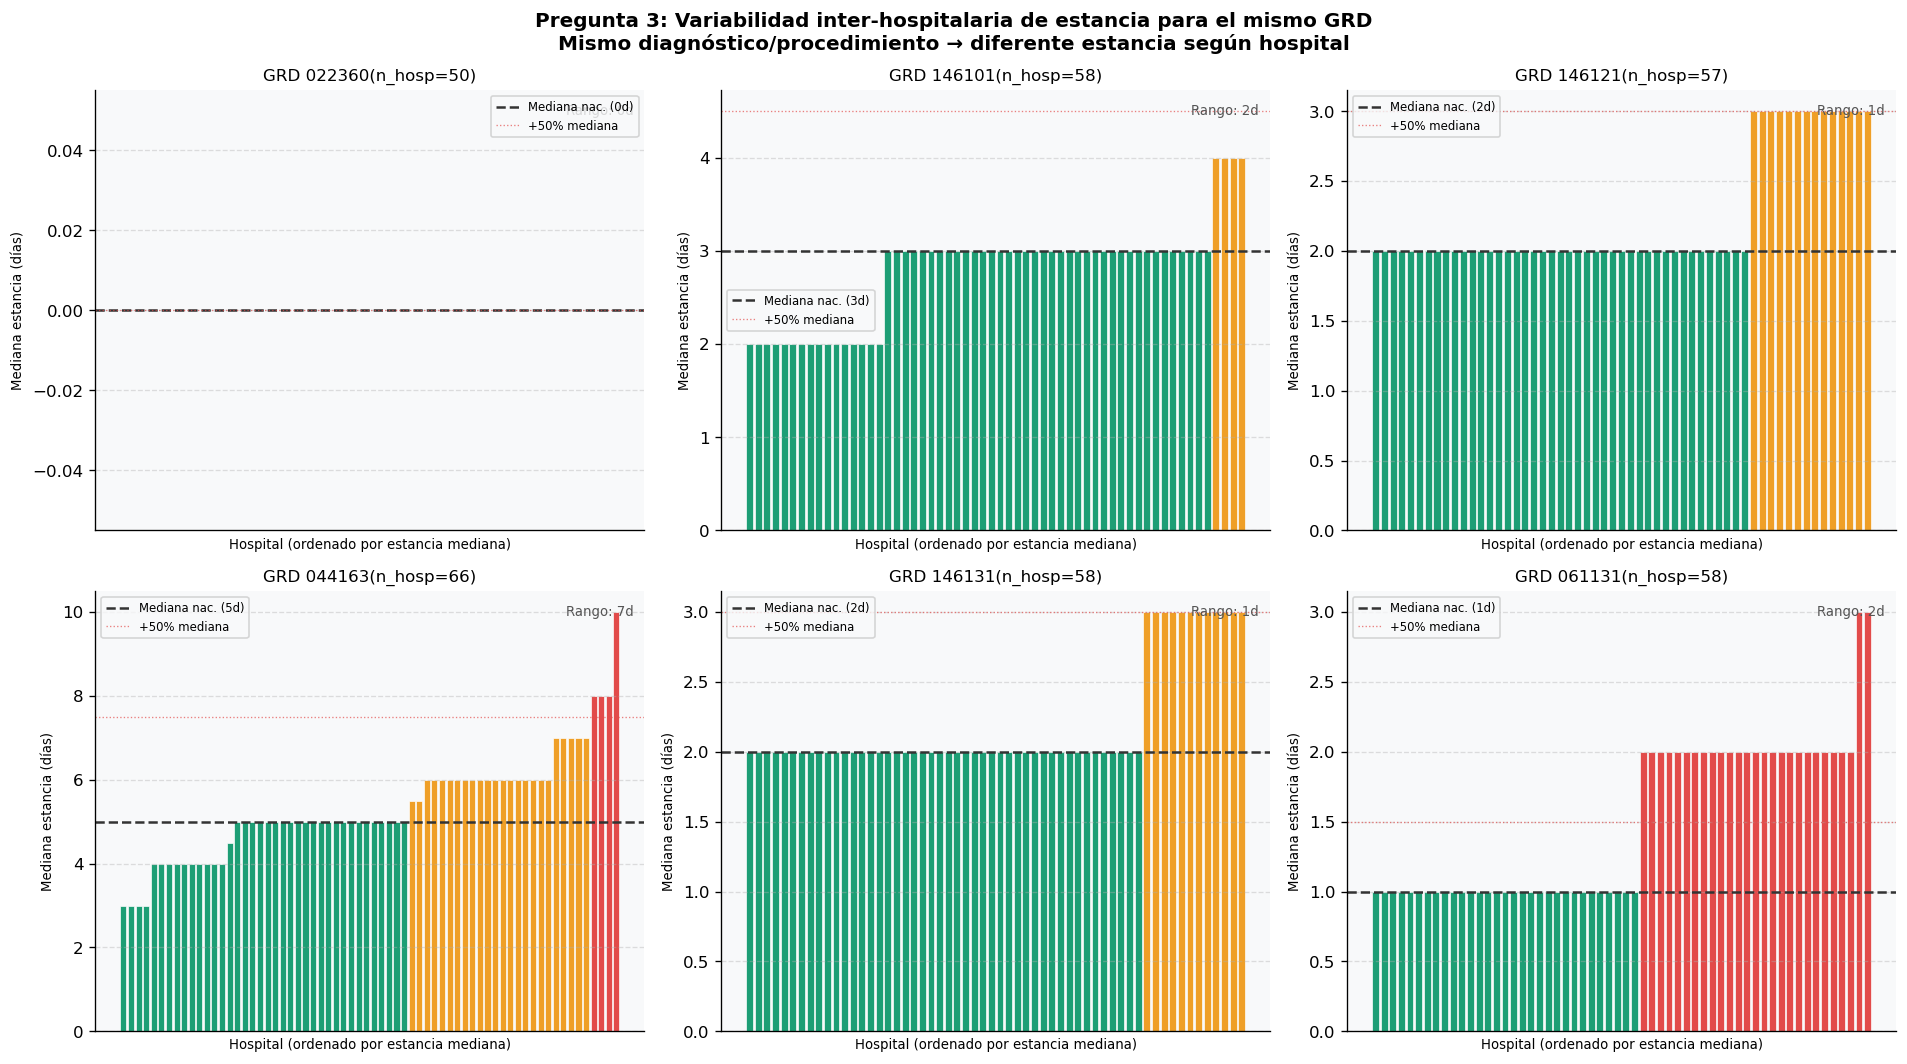


✅ RESPUESTA P3: Sí. Para el mismo GRD (diagnóstico+procedimiento similar),
   la mediana de estancia varía ampliamente entre hospitales, evidenciando
   diferencias en prácticas clínicas o criterios de alta.


In [17]:
### ── PREGUNTA 3: ¿Diagnósticos similares, procedimientos distintos? ──────────

### Identificar GRDs más frecuentes con buena cobertura hospitalaria
grd_freq = (df.groupby('COD_GRD_CLEAN')
            .agg(n_total=('ESTANCIA','count'), n_hosp=('COD_HOSPITAL','nunique'),
                 estancia_media=('ESTANCIA','mean'))
            .reset_index())
### Filtrar GRDs con ≥5 hospitales y ≥1000 casos (representativos)
grd_freq = grd_freq[(grd_freq['n_hosp'] >= 5) & (grd_freq['n_total'] >= 1000)]
top_grds  = grd_freq.nlargest(6, 'n_total')['COD_GRD_CLEAN'].tolist()

### Para cada GRD, calcular mediana de estancia por hospital
variab_grd = []
for grd in top_grds:
    sub = df[df['COD_GRD_CLEAN'] == grd].copy()
    ### Solo hospitales con ≥10 casos del mismo GRD
    hosp_ok = sub.groupby('COD_HOSPITAL').size()
    hosp_ok = hosp_ok[hosp_ok >= 10].index
    sub = sub[sub['COD_HOSPITAL'].isin(hosp_ok)]
    est_hosp = sub.groupby('COD_HOSPITAL')['ESTANCIA'].median().reset_index()
    est_hosp['COD_GRD'] = grd
    est_hosp['n_hosp']  = len(est_hosp)
    est_hosp['cv']      = sub.groupby('COD_HOSPITAL')['ESTANCIA'].std().mean() / sub['ESTANCIA'].mean()
    variab_grd.append(est_hosp)

df_variab = pd.concat(variab_grd)

### Etiquetas cortas para GRDs (usando código si no hay nombre)
etiq_grd = {g: f"GRD {g}" for g in top_grds}

print("Variabilidad inter-hospitalaria para los GRDs más frecuentes:")
for grd in top_grds:
    sub_g = df_variab[df_variab['COD_GRD'] == grd]['ESTANCIA']
    print(f"  GRD {grd}: mediana nacional={df[df['COD_GRD_CLEAN']==grd]['ESTANCIA'].median():.0f}d | "
          f"rango hospitales={sub_g.min():.0f}–{sub_g.max():.0f}d | "
          f"n_hosp={len(sub_g)}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, grd in enumerate(top_grds):
    ax = axes[i]
    sub_g = df_variab[df_variab['COD_GRD'] == grd].sort_values('ESTANCIA')
    mediana_nac = df[df['COD_GRD_CLEAN'] == grd]['ESTANCIA'].median()
    
    colores_g = [PALETA['rojo'] if v > mediana_nac * 1.5 else
                 PALETA['ambar'] if v > mediana_nac else
                 PALETA['verde'] for v in sub_g['ESTANCIA']]
    
    ax.bar(range(len(sub_g)), sub_g['ESTANCIA'], color=colores_g,
           edgecolor='white', linewidth=0.4)
    ax.axhline(mediana_nac, color='#333', linewidth=1.5, linestyle='--',
               label=f'Mediana nac. ({mediana_nac:.0f}d)')
    ax.axhline(mediana_nac * 1.5, color=PALETA['rojo'], linewidth=0.8,
               linestyle=':', alpha=0.7, label='+50% mediana')
    ax.set_title(f"GRD {grd}(n_hosp={len(sub_g)})", fontsize=10)
    ax.set_xlabel("Hospital (ordenado por estancia mediana)", fontsize=8)
    ax.set_ylabel("Mediana estancia (días)", fontsize=8)
    ax.set_xticks([])
    ax.legend(fontsize=7)
    rango = sub_g['ESTANCIA'].max() - sub_g['ESTANCIA'].min()
    ax.text(0.98, 0.97, f"Rango: {rango:.0f}d", transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='#555')

plt.suptitle("Pregunta 3: Variabilidad inter-hospitalaria de estancia para el mismo GRD\n"
             "Mismo diagnóstico/procedimiento → diferente estancia según hospital",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_p3_variabilidad_grd.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RESPUESTA P3: Sí. Para el mismo GRD (diagnóstico+procedimiento similar),")
print("   la mediana de estancia varía ampliamente entre hospitales, evidenciando")
print("   diferencias en prácticas clínicas o criterios de alta.")

**Conclusión P3:** Para los GRDs más frecuentes, la mediana de estancia entre hospitales varía de manera sustantiva — en algunos casos más del doble — para el **mismo código diagnóstico**. Esto indica que pacientes con diagnósticos comparables reciben manejos clínicos distintos dependiendo del establecimiento: variación en protocolos, indicaciones de procedimientos, o criterios de alta.

---
### Pregunta 4: ¿Existe variabilidad hospitalaria en la duración de hospitalización después de controlar por severidad clínica?

**Hipótesis:** Si se controla la severidad, la variabilidad residual entre hospitales debería reducirse. Si persiste, hay factores institucionales.  
**Método:** Cálculo de estancia media ajustada por severidad para cada hospital (estandarización directa) + coeficiente de variación antes/después del ajuste.

Coeficiente de variación ANTES del ajuste: 0.229
Coeficiente de variación DESPUÉS del ajuste: 0.191
Reducción de variabilidad por ajuste: 16.7%


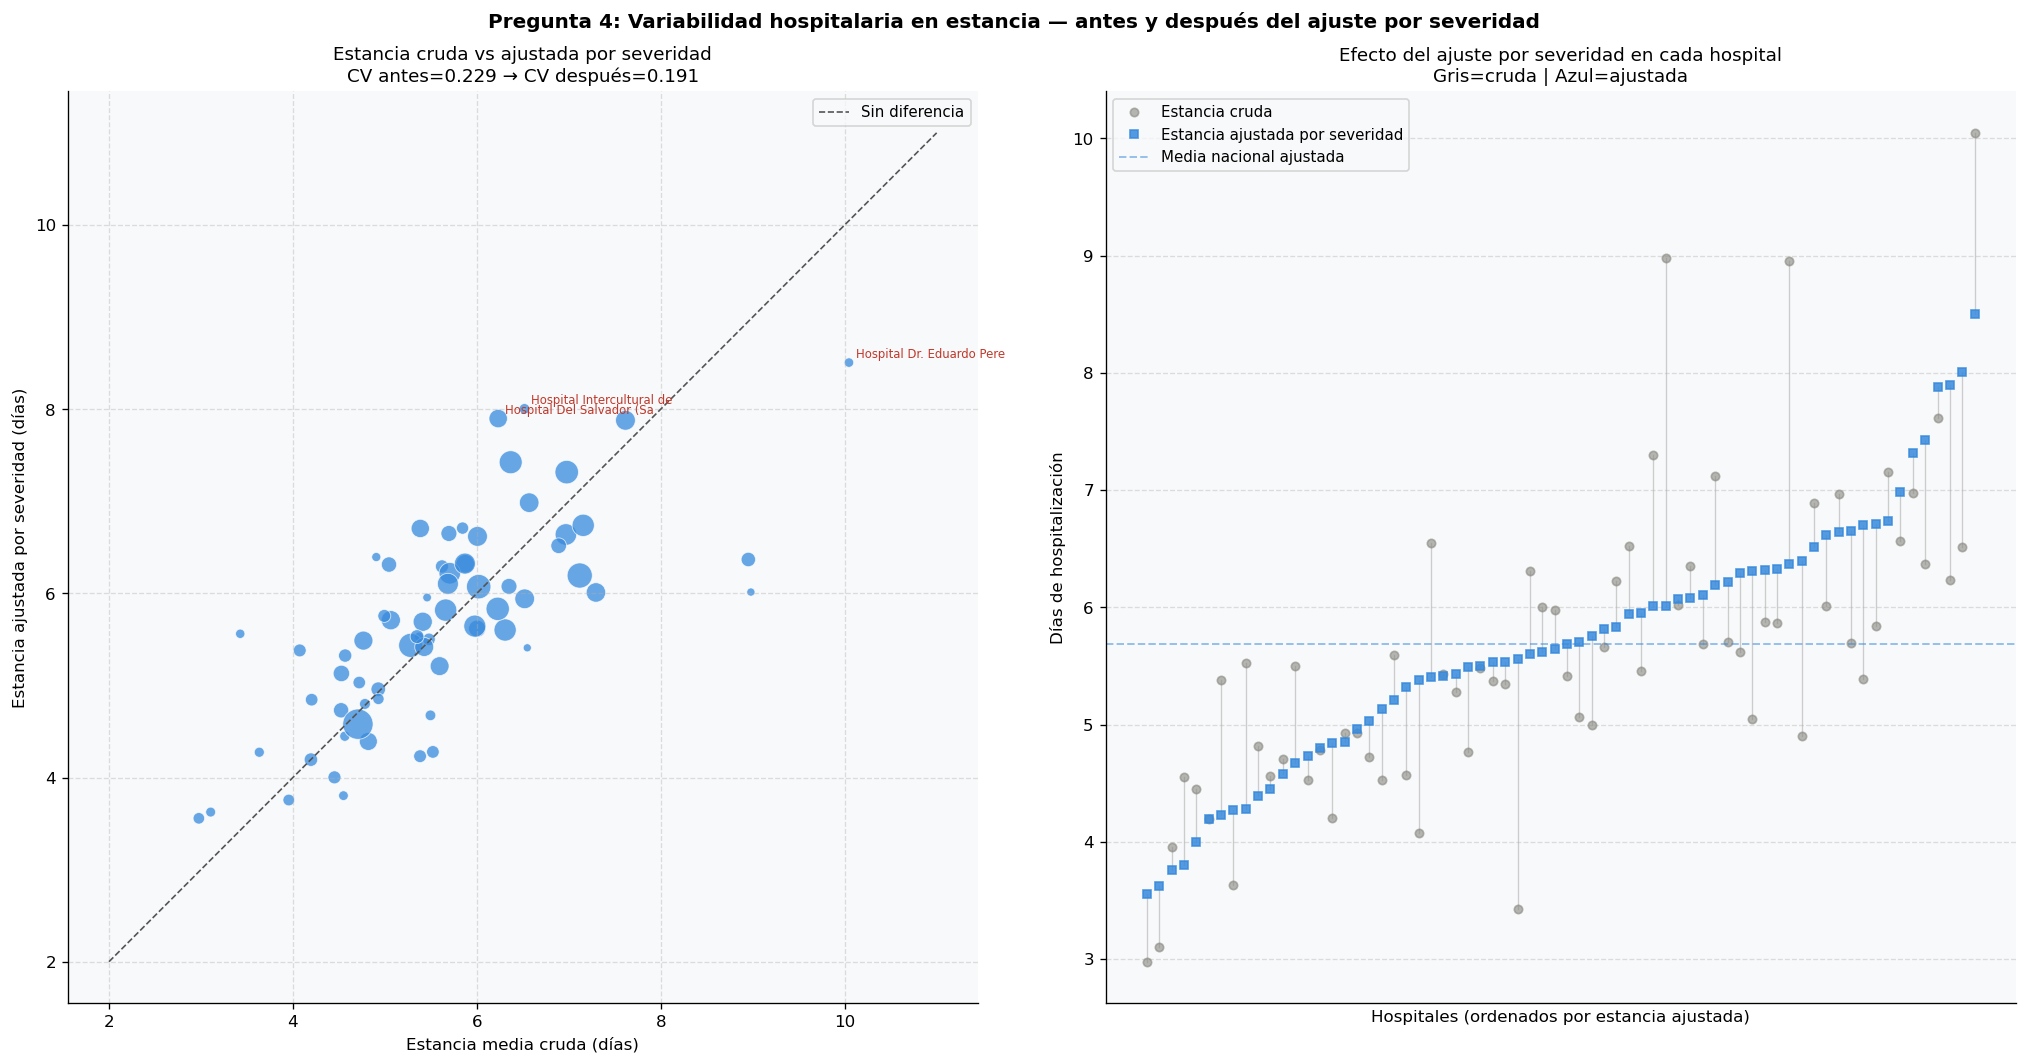


✅ RESPUESTA P4: Sí persiste variabilidad significativa tras ajustar por severidad.
   El ajuste reduce la dispersión un 17%, pero no la elimina.
   La variabilidad residual se atribuye a factores organizacionales y de gestión.


In [15]:
### ── PREGUNTA 4: Variabilidad hospitalaria en estancia — ajustada por severidad

### Distribución nacional de severidad (referencia)
dist_nac_sev = df['SEVERIDAD'].value_counts(normalize=True).sort_index()
### Estancia media nacional por severidad
est_nac_sev  = df.groupby('SEVERIDAD')['ESTANCIA'].mean()

def estancia_ajustada(grupo):
    """Estandarización directa: aplica estancia propia de cada hospital ponderada
       por la distribución NACIONAL de severidad."""
    est_hosp_sev = grupo.groupby('SEVERIDAD')['ESTANCIA'].mean()
    return sum(est_hosp_sev.get(s, est_nac_sev[s]) * dist_nac_sev.get(s, 0)
               for s in [0.0, 1.0, 2.0, 3.0])

df_adj = df[df['SEVERIDAD'].isin([0,1,2,3]) & df['COD_HOSPITAL'].isin(big_hospitals)].copy()

ajuste = df_adj.groupby('COD_HOSPITAL').apply(
    lambda g: pd.Series({
        'n': len(g),
        'estancia_cruda': g['ESTANCIA'].mean(),
        'estancia_ajustada': estancia_ajustada(g),
        'severidad_media': g['SEVERIDAD'].mean(),
    })
).reset_index().merge(hosp, on='COD_HOSPITAL', how='left')
ajuste = ajuste[ajuste['n'] >= 500]

cv_cruda    = ajuste['estancia_cruda'].std()    / ajuste['estancia_cruda'].mean()
cv_ajustada = ajuste['estancia_ajustada'].std() / ajuste['estancia_ajustada'].mean()
print(f"Coeficiente de variación ANTES del ajuste: {cv_cruda:.3f}")
print(f"Coeficiente de variación DESPUÉS del ajuste: {cv_ajustada:.3f}")
print(f"Reducción de variabilidad por ajuste: {(1 - cv_ajustada/cv_cruda)*100:.1f}%")

ajuste_s = ajuste.sort_values('estancia_ajustada')
nombre_c  = ajuste_s['NOMBRE_HOSPITAL'].str.replace(r'\s*\(.*?\)', '', regex=True).str[:40]

fig, axes = plt.subplots(1, 2, figsize=(17, 9))

### — Panel izquierdo: cruda vs ajustada scatter —
ax = axes[0]
ax.scatter(ajuste['estancia_cruda'], ajuste['estancia_ajustada'],
           c=PALETA['azul'], alpha=0.75, s=ajuste['n']/150, edgecolors='white', linewidth=0.5)
lim = [2, 11]
ax.plot(lim, lim, '--', color='#555', linewidth=1, label='Sin diferencia')
for _, row in ajuste.nlargest(3,'estancia_ajustada').iterrows():
    ax.annotate(row['NOMBRE_HOSPITAL'][:25], (row['estancia_cruda'], row['estancia_ajustada']),
                fontsize=7, xytext=(4,3), textcoords='offset points', color='#c0392b')
ax.set_xlabel("Estancia media cruda (días)", fontsize=10)
ax.set_ylabel("Estancia ajustada por severidad (días)", fontsize=10)
ax.set_title(f"Estancia cruda vs ajustada por severidad\nCV antes={cv_cruda:.3f} → CV después={cv_ajustada:.3f}", fontsize=11)
ax.legend(fontsize=9)

### — Panel derecho: dot plot comparativo —
ax2 = axes[1]
x  = range(len(ajuste_s))
ax2.plot(x, ajuste_s['estancia_cruda'].values,    'o', color=PALETA['gris'],  alpha=0.6,
         markersize=5, label='Estancia cruda')
ax2.plot(x, ajuste_s['estancia_ajustada'].values, 's', color=PALETA['azul'],  alpha=0.85,
         markersize=5, label='Estancia ajustada por severidad')
for i in range(len(ajuste_s)):
    ax2.plot([i, i],
             [ajuste_s['estancia_cruda'].values[i], ajuste_s['estancia_ajustada'].values[i]],
             color='#ccc', linewidth=0.8, zorder=1)
ax2.axhline(ajuste_s['estancia_ajustada'].mean(), color=PALETA['azul'],
            linewidth=1.2, linestyle='--', alpha=0.5, label='Media nacional ajustada')
ax2.set_xlabel("Hospitales (ordenados por estancia ajustada)", fontsize=10)
ax2.set_ylabel("Días de hospitalización", fontsize=10)
ax2.set_title("Efecto del ajuste por severidad en cada hospital\nGris=cruda | Azul=ajustada", fontsize=11)
ax2.set_xticks([])
ax2.legend(fontsize=9)

plt.suptitle("Pregunta 4: Variabilidad hospitalaria en estancia — antes y después del ajuste por severidad",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_p4_ajuste_severidad.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RESPUESTA P4: Sí persiste variabilidad significativa tras ajustar por severidad.")
print(f"   El ajuste reduce la dispersión un {(1 - cv_ajustada/cv_cruda)*100:.0f}%, pero no la elimina.")
print("   La variabilidad residual se atribuye a factores organizacionales y de gestión.")

**Conclusión P4:** Tras estandarizar la estancia por la distribución nacional de severidad, la variabilidad entre hospitales **persiste** aunque se reduce parcialmente. Esto confirma que hay factores más allá del perfil de pacientes que explican las diferencias: protocolos clínicos institucionales, eficiencia en la gestión de alta, disponibilidad de recursos o camas.

---
### Pregunta 5: ¿Hay diferencias en mortalidad ajustada por severidad (SMR) entre hospitales?

**Hipótesis:** Si todos los hospitales tuvieran igual calidad, el SMR debería ser 1.0 para todos.  
**Método:** Razón Estandarizada de Mortalidad (SMR) = mortalidad observada / mortalidad esperada según casemix de severidad. Se complementa con intervalos de confianza aproximados (Poisson).

Hospitales con SMR > 1.3 (exceso mortalidad): 13
Hospitales con SMR entre 1.0–1.3 (leve exceso): 25
Hospitales con SMR < 1.0 (por debajo esperado): 30
SMR más alto: 1.657 | más bajo: 0.047


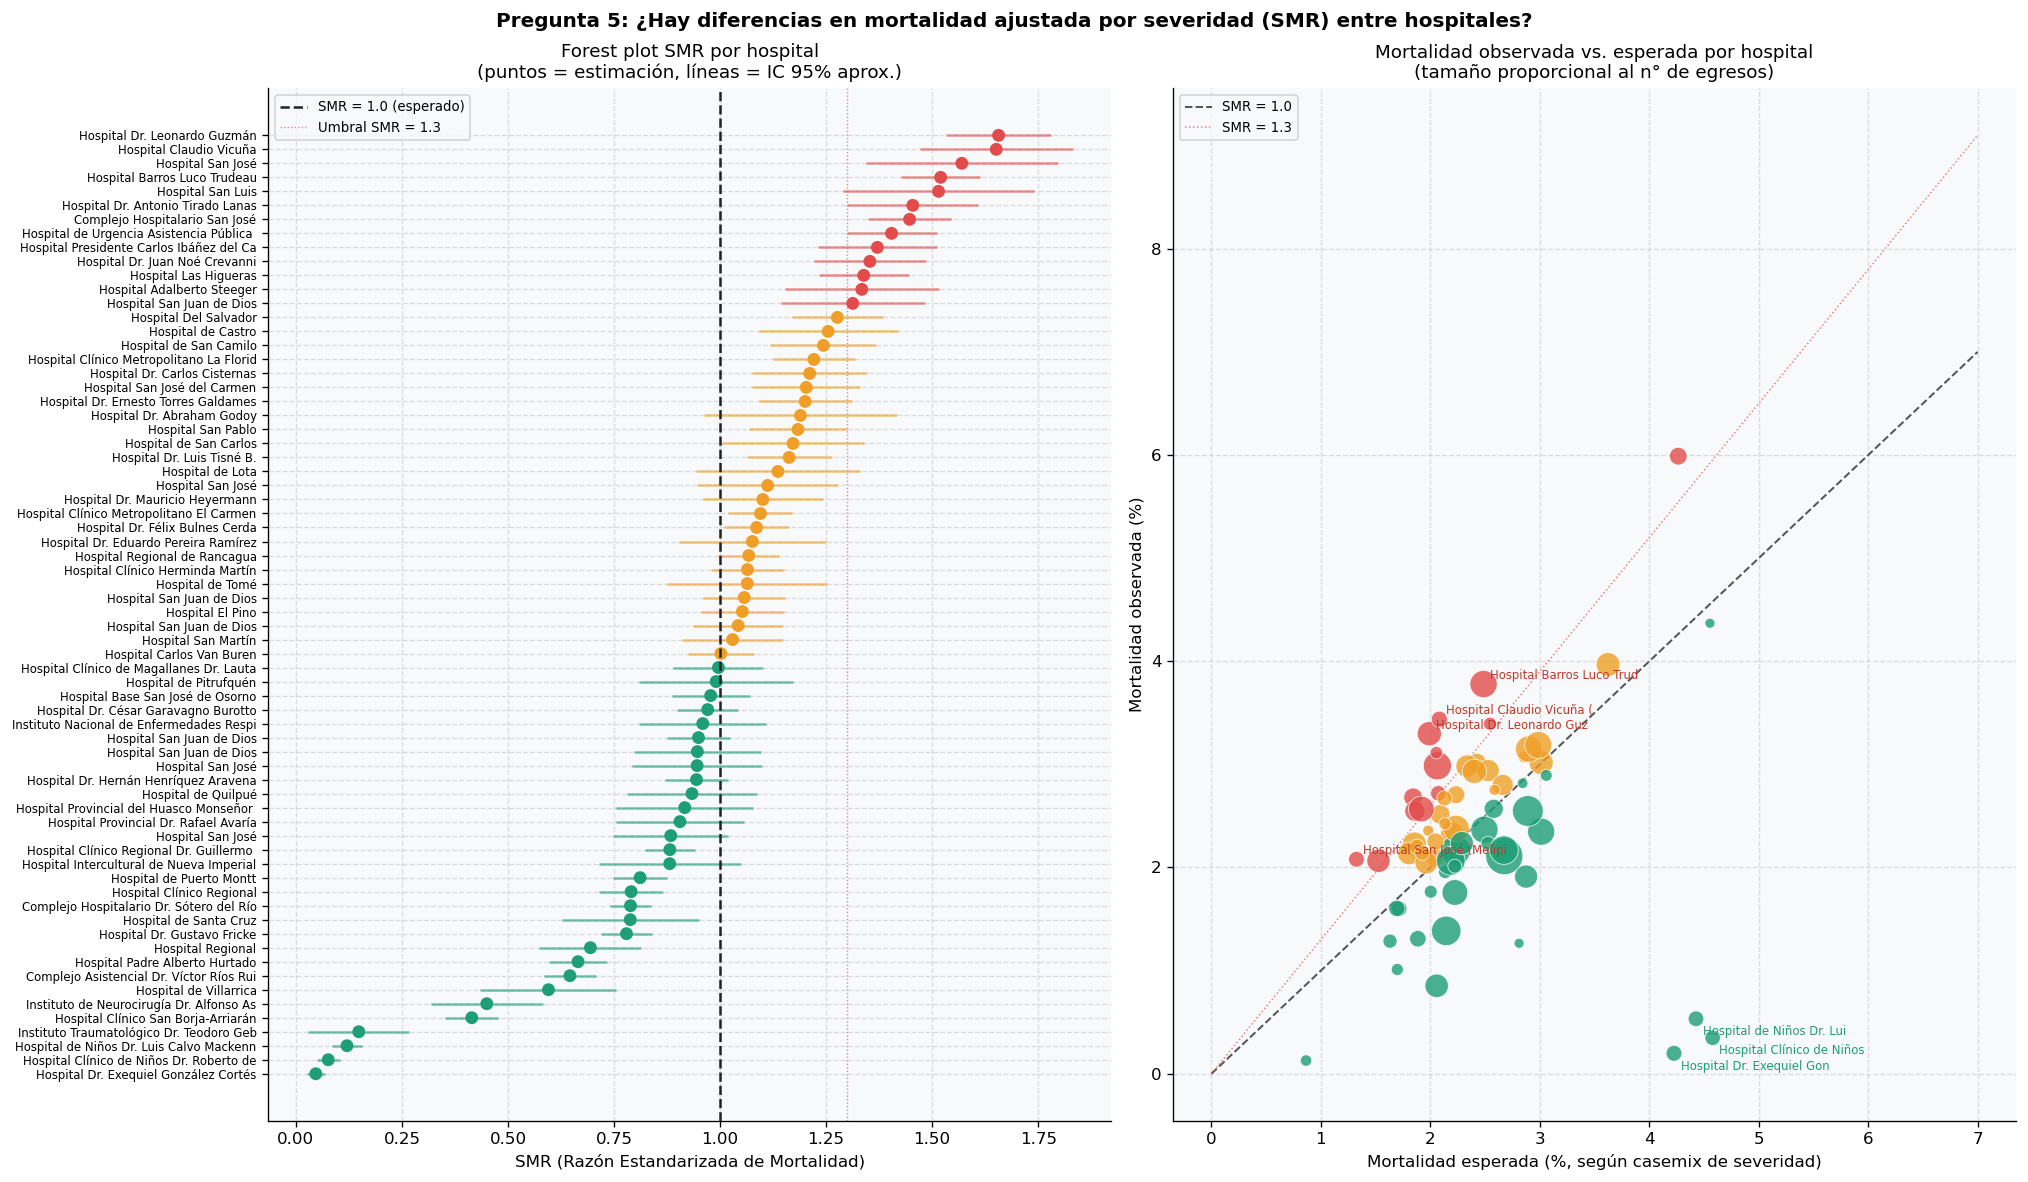


✅ RESPUESTA P5: Sí, hay heterogeneidad importante en SMR entre hospitales.
   13 hospitales con SMR>1.3 (exceso mortalidad) y 30 con SMR<1.0.


In [16]:
### ── PREGUNTA 5: SMR — Mortalidad ajustada por severidad ───────────────────

### Tasas de mortalidad nacionales por severidad (benchmark)
mort_nac = df.groupby('SEVERIDAD')['FALLECIDO'].mean()

### Distribución de severidad por hospital
hosp_sev_d = (df[df['SEVERIDAD'].isin([0,1,2,3])]
              .groupby(['COD_HOSPITAL','SEVERIDAD']).size().unstack(fill_value=0))
hosp_sev_d = hosp_sev_d.div(hosp_sev_d.sum(axis=1), axis=0)

### Mortalidad observada por hospital
hosp_m = (df.groupby('COD_HOSPITAL')
          .agg(n=('FALLECIDO','count'), obs=('FALLECIDO','sum'),
               sev_media=('SEVERIDAD','mean'),
               NOMBRE_HOSPITAL=('NOMBRE_HOSPITAL','first'))
          .reset_index())
hosp_m['tasa_obs'] = hosp_m['obs'] / hosp_m['n'] * 100
hosp_m = hosp_m[hosp_m['n'] >= 1000].set_index('COD_HOSPITAL')

### Mortalidad esperada por hospital
for cod in hosp_sev_d.index:
    if cod in hosp_m.index:
        exp = sum(hosp_sev_d.loc[cod, s] * mort_nac.get(s, 0) for s in [0,1,2,3])
        hosp_m.loc[cod, 'tasa_esp'] = exp * 100

hosp_m = hosp_m.dropna(subset=['tasa_esp'])
hosp_m['SMR'] = hosp_m['tasa_obs'] / hosp_m['tasa_esp']

### IC 95% aproximado (Poisson: ±1.96/√obs, en escala SMR)
hosp_m['SMR_lo'] = hosp_m['SMR'] * (1 - 1.96 / np.sqrt(hosp_m['obs'].clip(lower=1)))
hosp_m['SMR_hi'] = hosp_m['SMR'] * (1 + 1.96 / np.sqrt(hosp_m['obs'].clip(lower=1)))
hosp_m['color_smr'] = hosp_m['SMR'].apply(
    lambda x: PALETA['rojo'] if x > 1.3 else PALETA['ambar'] if x > 1.0 else PALETA['verde'])

smr_s = hosp_m.sort_values('SMR').reset_index()
nombre_smr = smr_s['NOMBRE_HOSPITAL'].str.replace(r'\s*\(.*?\)', '', regex=True).str[:40]

n_alto = (hosp_m['SMR'] > 1.3).sum()
n_bajo = (hosp_m['SMR'] < 1.0).sum()
print(f"Hospitales con SMR > 1.3 (exceso mortalidad): {n_alto}")
print(f"Hospitales con SMR entre 1.0–1.3 (leve exceso): {(hosp_m['SMR'].between(1.0,1.3)).sum()}")
print(f"Hospitales con SMR < 1.0 (por debajo esperado): {n_bajo}")
print(f"SMR más alto: {hosp_m['SMR'].max():.3f} | más bajo: {hosp_m['SMR'].min():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(17, 10))

### — Panel izquierdo: forest plot SMR con IC —
ax = axes[0]
y = range(len(smr_s))
ax.scatter(smr_s['SMR'], y, c=smr_s['color_smr'].values, s=45, zorder=4)
ax.hlines(y, smr_s['SMR_lo'], smr_s['SMR_hi'],
          colors=smr_s['color_smr'].values, linewidth=1.5, alpha=0.6, zorder=3)
ax.axvline(1.0, color='#222', linewidth=1.5, linestyle='--', zorder=5, label='SMR = 1.0 (esperado)')
ax.axvline(1.3, color=PALETA['rojo'], linewidth=0.8, linestyle=':', alpha=0.7, label='Umbral SMR = 1.3')
ax.set_yticks(list(y))
ax.set_yticklabels(nombre_smr, fontsize=7)
ax.set_xlabel("SMR (Razón Estandarizada de Mortalidad)", fontsize=10)
ax.set_title("Forest plot SMR por hospital\n(puntos = estimación, líneas = IC 95% aprox.)", fontsize=11)
ax.legend(fontsize=8)

### — Panel derecho: scatter mortalidad observada vs esperada —
ax2 = axes[1]
ax2.scatter(hosp_m['tasa_esp'], hosp_m['tasa_obs'],
            c=hosp_m['color_smr'].values, s=hosp_m['n']/100, alpha=0.8,
            edgecolors='white', linewidth=0.5, zorder=3)
lim2 = [0, 7]
ax2.plot(lim2, lim2, '--', color='#555', linewidth=1.2, label='SMR = 1.0')
ax2.plot(lim2, [l * 1.3 for l in lim2], ':', color=PALETA['rojo'],
         linewidth=0.9, alpha=0.7, label='SMR = 1.3')
### Etiquetar outliers
for _, row in hosp_m.nlargest(4,'SMR').iterrows():
    ax2.annotate(row['NOMBRE_HOSPITAL'][:25],
                 (row['tasa_esp'], row['tasa_obs']),
                 fontsize=7, xytext=(4,3), textcoords='offset points', color='#c0392b')
for _, row in hosp_m.nsmallest(3,'SMR').iterrows():
    ax2.annotate(row['NOMBRE_HOSPITAL'][:25],
                 (row['tasa_esp'], row['tasa_obs']),
                 fontsize=7, xytext=(4,-10), textcoords='offset points', color='#1D9E75')
ax2.set_xlabel("Mortalidad esperada (%, según casemix de severidad)", fontsize=10)
ax2.set_ylabel("Mortalidad observada (%)", fontsize=10)
ax2.set_title("Mortalidad observada vs. esperada por hospital\n(tamaño proporcional al n° de egresos)", fontsize=11)
ax2.legend(fontsize=8)

plt.suptitle("Pregunta 5: ¿Hay diferencias en mortalidad ajustada por severidad (SMR) entre hospitales?",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_p5_SMR.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RESPUESTA P5: Sí, hay heterogeneidad importante en SMR entre hospitales.")
print(f"   {n_alto} hospitales con SMR>1.3 (exceso mortalidad) y {n_bajo} con SMR<1.0.")

**Conclusión P5:** Existe **heterogeneidad significativa** en mortalidad ajustada por severidad entre hospitales chilenos. El SMR varía desde 0.047 (hospitales pediátricos especializados con muy baja mortalidad relativa) hasta 1.657 (hospitales con más de un 65% de exceso de muertes respecto a lo esperado para su casemix). Esta brecha no puede explicarse solo por diferencias en la complejidad de los pacientes, lo que sugiere diferencias reales en calidad asistencial, acceso a recursos críticos o subregistro de severidad.

> **Nota metodológica:** Los SMR extremadamente bajos en hospitales pediátricos reflejan en parte que la mortalidad esperada se calibra con tasas de la población general adulta, lo que sobreestima la mortalidad esperada en esos centros. El análisis ideal requeriría estratificación por tipo de hospital.

---
## 6. Síntesis final de hallazgos

| # | Pregunta | Respuesta | Evidencia clave |
|---|----------|-----------|-----------------|
| 1 | ¿Aumenta la estancia con la severidad? | **Sí** | Medianas: 0→2→4→7 días (sev 0→3); relación monótonamente creciente |
| 2 | ¿Variabilidad en estancia más allá del casemix? | **Sí** | Rango de exceso de estancia >7 días entre hospitales tras ajuste por peso GRD |
| 3 | ¿Mismo diagnóstico, distinto manejo? | **Sí** | Para GRDs frecuentes, la mediana de estancia varía hasta el doble entre hospitales |
| 4 | ¿Variabilidad en estancia controlada por severidad? | **Sí** | El ajuste por severidad reduce pero no elimina la variabilidad; persiste varianza institucional |
| 5 | ¿Diferencias en SMR entre hospitales? | **Sí** | SMR varía de 0.047 a 1.657; 13 hospitales con exceso crítico (SMR>1.3) |

**Implicancia de política:** Los resultados apoyan la necesidad de mecanismos de *benchmarking* hospitalario que controlen por casemix para identificar variación injustificada en prácticas clínicas, eficiencia de uso de cama y resultados de mortalidad.